# Regime-Aware Bayesian Deferral for Seismic Phase Picking

**Team:** Seraphina Korompis & Yasmin Akhmedova

**Programme:** MSc AI Applications and Innovation

**Module:** ELEC70122: Machine Learning for Safety Critical Decision-Making

**Date:** March 2026

## Project Overview

This notebook implements a regime-aware Bayesian deferral framework for seismic phase picking. PhaseNet, a deep learning model trained on Northern California earthquake data, is applied to Kazakhstan, a seismically active but data-sparse region. The core question is not whether PhaseNet works in Kazakhstan, but whether we can build a system that knows when it does not work, and defers uncertain decisions to human seismologists.

The notebook proceeds in two stages. First, we verify that sufficient data exists in Kazakhstan for the analysis (station availability, event catalog, ground truth picks, and sample waveforms). Second, we establish a California baseline by running PhaseNet on in-distribution data and measuring its performance against human-reviewed picks. These baselines are essential for quantifying the distribution shift that motivates the deferral framework.

### Imports and Configuration

In addition to the standard libraries for handling numerical computations, data analysis and visualisation, we use two key libraries throughout this notebook:

- `ObsPy` for retrieving seismological data via FDSN (International Federation of Digital Seismograph Networks) web services, which provide standardised access to global earthquake catalogues and waveform data; and
- `SeisBench` for its standardised interface to machine learning models for seismology, including PhaseNet.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import seisbench.models as sbm
from obspy import UTCDateTime, Stream, Trace
from obspy.clients.fdsn import Client
from obspy.geodetics import locations2degrees
from scipy import stats

# FDSN client for accessing seismic data from IRIS/EarthScope
client_iris = Client("IRIS", timeout = 120)

# Global plot configuration
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 200
plt.rcParams["font.size"] = 12

---

## Step 1: Data Availability Check for Kazakhstan (2020--2023)

Before building any models, we need to verify that sufficient data exists for the Kazakhstan analysis. This step checks four things: station availability, the earthquake event catalog, ground truth phase picks, and whether we can download and process sample waveforms. If any of these checks fail, the project scope would need to be adjusted.

---

**Why 2020--2023?**

We restrict our analysis to 2020--2023 for two reasons. First, we need all stations to have stable, unchanged instrumentation throughout the study window, so that changes in PhaseNet's performance can be attributed to seismic regime shifts rather than sensor changes. We verified that no station experienced a mid-study sensor change. The earliest start date is constrained by BORK (operational from August 2019) and KURK (upgraded to its current STS-6 sensor in September 2019), making 2020 the first full calendar year where all stations are on stable instrumentation. Second, we take 2023 as the upper limit because the ISC (International Seismological Centre) Reviewed Bulletin (http://www.isc.ac.uk/iscbulletin/), which provides human-analyst-verified arrival times we use as ground truth, is currently reviewed up to December 2023. Without these reviewed picks, we cannot evaluate PhaseNet's accuracy or update the reliability model.

**Why these KZ stations?**

We queried the IRIS (Incorporated Research Institutions for Seismology, now part of EarthScope Consortium) FDSN (International Federation of Digital Seismograph Networks) web service for all stations in the KZ (Kazakhstan) network with three-component broadband channels (BH*) during 2020--2023, which returned 29 stations. After removing experiment/temporary deployments (8 stations) and verifying actual waveform data availability (as opposed to metadata-only entries), 12 stations had confirmed downloadable three-component broadband data with stable instrumentation across the study window. One station (KUR21) was subsequently excluded because it had zero ISC-reviewed picks (see Step 1c), leaving 11 stations providing geographic coverage across Kazakhstan. Although the 11 stations use six different broadband sensor types (STS-6, STS-2, CMG3-TB, KS-54000, CMG3-ESP, Trillium 120), all sample at 40 Hz. The critical requirement is not that all stations share identical hardware, but that each station's instrumentation remains stable across the study window, so that changes in PhaseNet's performance can be attributed to seismic regime shifts rather than sensor changes.

**Data cleaning steps:**

1. Query all KZ network stations with BH* channels
2. Filter to three-component stations
3. Remove experiment/temporary stations
4. Verify waveform availability
5. Verify instrument stability
6. Exclude stations with no ISC-reviewed picks
7. Result: 11 stations

### Step 1a: Station Availability Check

We query the IRIS FDSN web service for all stations in the KZ (Kazakhstan) network with three-component broadband channels (BH*: BHZ for vertical, BHN/BH1 for north-south, BHE/BH2 for east-west) during 2020--2023. PhaseNet requires three-component broadband input, so stations with only single-component vertical sensors are excluded. We then verify which stations have actual waveform data available for download (as opposed to metadata-only entries) and confirm that no station experienced an instrument change during the study window.

In [2]:
# Query all three-component broadband stations in the KZ network
inv = client_iris.get_stations(
    network = "KZ",
    starttime = UTCDateTime("2020-01-01"),
    endtime = UTCDateTime("2023-12-31"),
    channel = "BH*",
    level = "channel"
)

# Build a summary per station, collecting all available channel codes
station_info = {}
for net in inv:
    for sta in net:
        code = sta.code
        if code not in station_info:
            station_info[code] = {
                "name": sta.site.name,
                "lat": sta.latitude,
                "lon": sta.longitude,
                "channels": set()
            }
        for ch in sta:
            station_info[code]["channels"].add(ch.code)

# Print only stations with at least 3 channels (i.e. three-component)
print(f"{'Station':<10} {'Channels':<25} {'Lat':>8} {'Lon':>8}  {'Name'}")
print("-" * 85)
count = 0
for code in sorted(station_info):
    info = station_info[code]
    chs = sorted(info["channels"])
    if len(chs) >= 3:
        print(f"{code:<10} {', '.join(chs):<25} {info['lat']:>8.4f} {info['lon']:>8.4f}  {info['name']}")
        count += 1
print(f"\nTotal 3-component BH* stations: {count}")

Station    Channels                       Lat      Lon  Name
-------------------------------------------------------------------------------------
ABKAR      BHE, BHN, BHZ              49.2556  59.9431  Akbulak array,AB31, Kazakhstan
AKTK       BH1, BH2, BHZ              50.4348  58.0167  Aktyubinsk, Kazakstan
AKTO       BH1, BH2, BHZ              50.4348  58.0164  Aktyubinsk, Kazakhstan
BAL5       BHE, BHN, BHZ              50.0423  78.6216  Eastern Kazakhstan experiment,  Balapan5
BAL6       BHE, BHN, BHZ              50.0641  78.8817  Eastern Kazakhstan experiment,  Balapan6
BORK       BHE, BHN, BHZ              53.0461  70.3184  Burabay, Kazakhstan
BRVK       BHE, BHN, BHZ              53.0580  70.2828  Borovoye, Kazakstan
BVAR       BH1, BH2, BHZ              53.0249  70.3885  Borovoye, Kazakstan
CHKZ       BHE, BHN, BHZ              53.6762  70.6152  Chkalovo, Kazakstan
DEG1       BHE, BHN, BHZ              49.7889  78.0498  Degelen experiment, site1, Kazakstan
DEG2       BHE, BH

In [3]:
# Remove experiment/temporary stations (identified by "experiment" in station name)
rows = []
for code in sorted(station_info):
    info = station_info[code]
    chs = sorted(info["channels"])
    if len(chs) >= 3:
        name_lower = info["name"].lower()
        is_experiment = "experiment" in name_lower
        if not is_experiment:
            rows.append({
                "Station": code,
                "Channels": ", ".join(chs),
                "Lat": info["lat"],
                "Lon": info["lon"],
                "Name": info["name"]
            })

df_filtered = pd.DataFrame(rows)
print(f"3-component BH* stations (excluding experiment stations): {len(df_filtered)}\n")
df_filtered

3-component BH* stations (excluding experiment stations): 21



,Station,Channels,Lat,Lon,Name
0,ABKAR,"BHE, BHN, BHZ",49.255600,59.943100,"Akbulak array,AB31, Kazakhstan"
1,AKTK,"BH1, BH2, BHZ",50.434799,58.016701,"Aktyubinsk, Kazakstan"
2,AKTO,"BH1, BH2, BHZ",50.434799,58.016399,"Aktyubinsk, Kazakhstan"
3,BORK,"BHE, BHN, BHZ",53.046101,70.318398,"Burabay, Kazakhstan"
4,BRVK,"BHE, BHN, BHZ",53.058000,70.282800,"Borovoye, Kazakstan"
5,BVAR,"BH1, BH2, BHZ",53.024921,70.388527,"Borovoye, Kazakstan"
6,CHKZ,"BHE, BHN, BHZ",53.676201,70.615196,"Chkalovo, Kazakstan"
7,KKAR,"BHE, BHN, BHZ",43.103401,70.511497,"Karatau array,KK31, Kazakhstan"
8,KNDC,"BHE, BHN, BHZ",43.217201,76.965797,"KNDC, Almaty, Kazakstan"
9,KUR,"BHE, BHN, BHZ",50.714901,78.620796,"Kurchatov, Kazakstan"


We now verify which of the remaining stations have actual waveform data available for download. Some stations have FDSN metadata entries but no downloadable waveforms. We test each station against four randomly chosen time windows spanning the study period.

In [4]:
# Check which stations have actual waveform data available
# (as opposed to metadata-only entries)
test_times = [
    UTCDateTime("2020-03-15T08:00:00"),
    UTCDateTime("2021-07-22T14:00:00"),
    UTCDateTime("2022-06-01T00:00:00"),
    UTCDateTime("2023-02-10T20:00:00"),
]

available = []
unavailable = []

for _, row in df_filtered.iterrows():
    hits = 0
    for t in test_times:
        try:
            st = client_iris.get_waveforms("KZ", row["Station"], "*", "BHZ", t, t + 60)
            hits += 1
        except:
            pass
    if hits > 0:
        available.append((row["Station"], hits))
    else:
        unavailable.append(row["Station"])

print(f"Data available: {len(available)} stations")
for sta, hits in available:
    print(f"  {sta:<10} {hits}/{len(test_times)} windows")

print(f"\nNo data in any window: {len(unavailable)} stations")
print(", ".join(unavailable))

Data available: 12 stations
  ABKAR      4/4 windows
  AKTO       4/4 windows
  BORK       3/4 windows
  BVAR       4/4 windows
  KKAR       4/4 windows
  KNDC       4/4 windows
  KUR21      4/4 windows
  KURK       4/4 windows
  MAKZ       4/4 windows
  MKAR       4/4 windows
  OTUK       1/4 windows
  PDGK       4/4 windows

No data in any window: 9 stations
AKTK, BRVK, CHKZ, KUR, MAK, TLG, VOS, ZRN, ZRNK


In [5]:
# Filter to stations with confirmed waveform data availability
available_codes = [sta for sta, hits in available]
df_available = df_filtered[df_filtered["Station"].isin(available_codes)].reset_index(drop = True)

print(f"Stations with confirmed waveform data: {len(df_available)}\n")
df_available

Stations with confirmed waveform data: 12



,Station,Channels,Lat,Lon,Name
0,ABKAR,"BHE, BHN, BHZ",49.255600,59.943100,"Akbulak array,AB31, Kazakhstan"
1,AKTO,"BH1, BH2, BHZ",50.434799,58.016399,"Aktyubinsk, Kazakhstan"
2,BORK,"BHE, BHN, BHZ",53.046101,70.318398,"Burabay, Kazakhstan"
3,BVAR,"BH1, BH2, BHZ",53.024921,70.388527,"Borovoye, Kazakstan"
4,KKAR,"BHE, BHN, BHZ",43.103401,70.511497,"Karatau array,KK31, Kazakhstan"
5,KNDC,"BHE, BHN, BHZ",43.217201,76.965797,"KNDC, Almaty, Kazakstan"
6,KUR21,"BH1, BH2, BHZ",50.622601,78.530403,"Kurchatov-Cross, Reference point, Kazakstan"
7,KURK,"BHE, BHN, BHZ",50.715400,78.620200,"Kurchatov, Kazakhstan"
8,MAKZ,"BHE, BHN, BHZ",46.807999,81.976997,"Makanchi, Kazakstan"
9,MKAR,"BHE, BHN, BHZ",46.793701,82.290398,"Makanchi array,MK31, Kazakhstan"


We now verify that each station's instrumentation remained stable throughout 2020--2023. If a station changed sensors mid-study, any change in PhaseNet's performance could be caused by the instrument change rather than a seismic regime shift. We query the instrument response metadata at the `response` level, which includes sensor description and operational dates.

In [6]:
# Check for instrument changes during the study period (2020--2023)
# A station with multiple sensor epochs would indicate a mid-study change
for _, row in df_available.iterrows():
    sta = row["Station"]
    inv = client_iris.get_stations(
        network = "KZ",
        station = sta,
        starttime = UTCDateTime("2020-01-01"),
        endtime = UTCDateTime("2023-12-31"),
        channel = "BH*",
        level = "response"
    )
    
    print(f"\n{'='*60}")
    print(f"Station: {sta}")
    print(f"{'='*60}")
    
    for net in inv:
        for s in net:
            for ch in s:
                if ch.code == "BHZ":
                    print(f"  {ch.code} | {ch.sensor.description} | "
                          f"{ch.start_date} to {ch.end_date or 'present'} | "
                          f"{ch.sample_rate} Hz")


Station: ABKAR
  BHZ | Geotech KS-54000 Borehole Seismometer | 2003-12-28T00:00:00.000000Z to present | 40.0 Hz

Station: AKTO
  BHZ | CMG3-TB | 2005-07-27T00:00:00.000000Z to present | 40.0 Hz

Station: BORK
  BHZ | Streckeisen STS-6 Seismometer | 2019-08-22T00:00:00.000000Z to present | 40.0 Hz

Station: BVAR
  BHZ | CMG3-TB | 2016-06-30T00:00:00.000000Z to present | 40.0 Hz

Station: KKAR
  BHZ | CMG3-TB | 2018-09-20T00:00:00.000000Z to present | 40.0 Hz

Station: KNDC
  BHZ | STS2 | 2011-12-25T00:00:00.000000Z to present | 40.0 Hz

Station: KUR21
  BHZ | CMG3-TB | 2006-09-25T00:00:00.000000Z to present | 40.0 Hz

Station: KURK
  BHZ | Streckeisen STS-6 Seismometer | 2019-09-01T12:00:00.000000Z to present | 40.0 Hz
  BHZ | Streckeisen STS-1V/VBB Seismometer | 2002-09-09T00:00:00.000000Z to present | 20.0 Hz

Station: MAKZ
  BHZ | STS2 | 2016-12-13T05:00:00.000000Z to present | 40.0 Hz

Station: MKAR
  BHZ | CMG3-TB | 2011-08-08T00:00:00.000000Z to present | 40.0 Hz

Station: OTUK
 

### Step 1b: Event Catalog Check

We download the earthquake event catalog from the International Seismological Centre (ISC) for the Central Asia / Kazakhstan region. The bounding box covers latitudes 41--55°N and longitudes 55--85°E, which encompasses all stations plus a 200km buffer to capture events that could trigger the Active regime at any station. We request all events with magnitude 3.0 or greater for the period 2020--2023.

The regime model requires at least 3--4 events with magnitude 5.0 or greater to define the Active regime. If fewer exist, we check magnitude 4.5 as a fallback threshold.

---

**Why ISC?**

We download the earthquake event catalog from the ISC because we need to know when and where significant earthquakes occurred in order to label time periods as Quiet, Active, or Decaying for the regime model. We use the ISC rather than alternatives like the USGS/NEIC catalog because the ISC Reviewed Bulletin integrates phase data from regional agencies including KNDC, producing more accurate locations and magnitudes for Central Asian events. Additionally, the ISC is the same source we use for human-reviewed phase picks in Step 1c, so using it for the event catalog ensures consistency between our regime labels and our ground truth.

**Why do we need a bounding box? Why do we need a buffer?**

We define a geographic bounding box to limit the catalog query to the Central Asia / Kazakhstan region. Without a bounding box, we would download the entire global catalog, which is unnecessarily large and includes events too far away to affect our stations.

We add a 200km buffer around the outermost stations because the regime model defines an Active regime when a significant earthquake occurs close enough to a station to affect waveform complexity. A magnitude 5+ earthquake just outside our station footprint could still produce overlapping, complex waveforms at a nearby station, so we need to capture these events. The 200km distance is a tunable parameter, not a hard physical boundary, and sensitivity analysis over different radii is a natural extension.

**Why all events with magnitude 3+?**

We request all events with magnitude 3.0 or greater because the HMM emission model uses event counts per time window to distinguish between regimes. The smaller events (magnitude 3--5) characterise the background event rate during Quiet periods and the elevated rate during Active and Decaying periods. If we only downloaded magnitude 5+ events, we would have the regime triggers but no information about the overall seismicity rate that differentiates one regime from another. We set the lower bound at 3.0 for two reasons. First, the Kazakhstan network's detection capability is complete down to approximately magnitude 3.5 (Mikhailova et al., 2015); below this, the network misses an increasing fraction of events, so event counts become unreliable. Setting our threshold slightly below completeness provides a small buffer without introducing significant detection bias. Second, events below magnitude 3 at regional distances produce very weak arrivals that PhaseNet would not be expected to pick, so there is no benefit to including them in the regime model.

**Why at least 3--4 events with magnitude 5+? Why 4.5 as a fallback threshold?**

The regime model needs enough transitions between Quiet and Active to actually learn something. If there is only one magnitude 5 event in four years, there is one regime transition and essentially no statistical power. Three to four events give enough Active periods to meaningfully estimate PhaseNet's reliability in that regime.

In [7]:
# Download the ISC earthquake event catalog for Central Asia / Kazakhstan
# Bounding box: 41-55°N, 55-85°E (covers all stations + 200km buffer)
client_isc = Client("ISC")

catalog = client_isc.get_events(
    starttime = UTCDateTime("2020-01-01"),
    endtime = UTCDateTime("2023-12-31"),
    minlatitude = 41,
    maxlatitude = 55,
    minlongitude = 55,
    maxlongitude = 85,
    minmagnitude = 3.0,
)
print(f"Total events with M >= 3.0: {len(catalog)}")

Total events with M >= 3.0: 6763


In [8]:
# Check for magnitude 4.5+ events (fallback threshold for regime transitions)
m45_events = [e for e in catalog if e.preferred_magnitude().mag >= 4.5]
print(f"Events with M >= 4.5: {len(m45_events)}")

Events with M >= 4.5: 12


In [9]:
# Print details of all M4.5+ events (time, location, depth)
for e in m45_events:
    origin = e.preferred_origin()
    mag = e.preferred_magnitude()
    print(f"M{mag.mag:.1f} | {origin.time.strftime('%Y-%m-%d %H:%M')} | "
          f"{origin.latitude:.2f}°N {origin.longitude:.2f}°E | {origin.depth/1000:.0f}km depth")

M5.2 | 2020-01-16 08:32 | 41.26°N 83.60°E | 8km depth
M4.5 | 2020-01-21 13:10 | 41.55°N 75.38°E | 1km depth
M4.7 | 2020-09-07 14:15 | 41.65°N 65.87°E | 10km depth
M4.5 | 2021-03-14 12:20 | 41.19°N 83.51°E | 10km depth
M5.0 | 2021-03-23 21:14 | 41.77°N 81.11°E | 11km depth
M4.6 | 2021-04-18 07:54 | 42.08°N 67.30°E | 10km depth
M5.1 | 2022-05-26 15:50 | 42.91°N 77.64°E | 21km depth
M4.5 | 2022-07-07 04:40 | 41.75°N 81.35°E | 10km depth
M5.0 | 2022-12-28 17:16 | 41.79°N 79.50°E | 16km depth
M4.5 | 2023-02-23 00:52 | 41.05°N 83.69°E | 10km depth
M4.6 | 2023-05-27 00:15 | 47.78°N 71.18°E | 0km depth
M4.8 | 2023-11-02 09:25 | 43.47°N 69.60°E | 0km depth


We now check which of the M4.5+ events fall within 200km of any station. Only events within this radius will trigger the Active regime at a given station. Events between 200--300km are shown as near-misses for context.

In [10]:
# Define station coordinates for proximity check
# (12 stations at this point; KUR21 will be removed after ISC pick check in Step 1c)
stations = {
    'ABKAR': (49.32, 59.94), 'AKTO': (50.43, 58.02),
    'BORK': (53.05, 70.28), 'BVAR': (53.00, 70.38),
    'KKAR': (43.10, 70.53), 'KNDC': (43.22, 77.00),
    'KUR21': (50.62, 78.47), 'KURK': (50.72, 78.56),
    'MAKZ': (46.81, 81.98), 'MKAR': (46.79, 82.29),
    'OTUK': (48.22, 72.34), 'PDGK': (43.26, 79.45),
}

# For each M4.5+ event, compute distance to all stations
# Flag events within 200km (Active regime trigger) and 300km (near-miss)
for e in m45_events:
    origin = e.preferred_origin()
    mag = e.preferred_magnitude()
    print(f"\nM{mag.mag:.1f} | {origin.time.strftime('%Y-%m-%d')} | {origin.latitude:.2f}°N {origin.longitude:.2f}°E")
    for name, (slat, slon) in stations.items():
        dist_deg = locations2degrees(origin.latitude, origin.longitude, slat, slon)
        dist_km = dist_deg * 111.195  # approximate conversion
        if dist_km <= 300:
            flag = " <-- WITHIN 200km" if dist_km <= 200 else ""
            print(f"  {name}: {dist_km:.0f}km{flag}")


M5.2 | 2020-01-16 | 41.26°N 83.60°E

M4.5 | 2020-01-21 | 41.55°N 75.38°E
  KNDC: 228km

M4.7 | 2020-09-07 | 41.65°N 65.87°E

M4.5 | 2021-03-14 | 41.19°N 83.51°E

M5.0 | 2021-03-23 | 41.77°N 81.11°E
  PDGK: 214km

M4.6 | 2021-04-18 | 42.08°N 67.30°E
  KKAR: 288km

M5.1 | 2022-05-26 | 42.91°N 77.64°E
  KNDC: 63km <-- WITHIN 200km
  PDGK: 152km <-- WITHIN 200km

M4.5 | 2022-07-07 | 41.75°N 81.35°E
  PDGK: 229km

M5.0 | 2022-12-28 | 41.79°N 79.50°E
  KNDC: 259km
  PDGK: 163km <-- WITHIN 200km

M4.5 | 2023-02-23 | 41.05°N 83.69°E

M4.6 | 2023-05-27 | 47.78°N 71.18°E
  OTUK: 99km <-- WITHIN 200km

M4.8 | 2023-11-02 | 43.47°N 69.60°E
  KKAR: 85km <-- WITHIN 200km


Of the 12 M4.5+ events in the catalog, only 4 fall within 200km of any station: KNDC sees 1 event (M5.1 at 63km), PDGK sees 2 events (M5.1 at 152km and M5.0 at 163km), OTUK sees 1 event (M4.6 at 99km), and KKAR sees 1 event (M4.8 at 85km). The remaining 8 stations (ABKAR, AKTO, BORK, BVAR, KUR21, KURK, MAKZ, MKAR) have no M4.5+ events within 200km and remain in the Quiet regime throughout 2020--2023. This provides a natural contrast: southern stations experience regime transitions for testing the deferral framework under Active conditions, while northern stations serve as Quiet-regime baselines. The small number of Active-regime transitions (4 events across 4 stations) is a limitation that should be acknowledged.

We now parse the catalog into a Pandas DataFrame for easier analysis and plotting. Each event record includes the origin time, location, depth, and preferred magnitude.

In [11]:
# Parse the ObsPy catalog into a Pandas DataFrame for easier analysis
event_records = []
for event in catalog:
    origin = event.preferred_origin()
    magnitude = event.preferred_magnitude()
    if origin is None or magnitude is None:
        continue
    event_records.append({
        "time": origin.time.datetime,
        "latitude": origin.latitude,
        "longitude": origin.longitude,
        "depth_km": origin.depth / 1000.0 if origin.depth is not None else np.nan,
        "magnitude": magnitude.mag,
        "mag_type": magnitude.magnitude_type,
    })

events_df = pd.DataFrame(event_records)
events_df["time"] = pd.to_datetime(events_df["time"])
events_df = events_df.sort_values("time").reset_index(drop = True)

# Print magnitude distribution summary
print(f"Events parsed: {len(events_df)}")
print(f"\nMagnitude distribution:")
for threshold in [3.0, 4.0, 4.5, 5.0, 5.5, 6.0]:
    count = len(events_df[events_df['magnitude'] >= threshold])
    print(f"  M >= {threshold}: {count}")

# Display the largest events
print(f"\nLargest events (M >= 5.0):")
large_events = events_df[events_df["magnitude"] >= 5.0].sort_values("magnitude", ascending = False)
if len(large_events) == 0:
    print("  None found. Checking M >= 4.5 as fallback...")
    large_events = events_df[events_df["magnitude"] >= 4.5].sort_values("magnitude", ascending = False)

for _, row in large_events.iterrows():
    print(f"  {row['time'].strftime('%Y-%m-%d %H:%M')} | "
          f"M{row['magnitude']:.1f} ({row['mag_type']}) | "
          f"{row['latitude']:.2f}N {row['longitude']:.2f}E | "
          f"depth {row['depth_km']:.0f} km")

Events parsed: 6763

Magnitude distribution:
  M >= 3.0: 5484
  M >= 4.0: 98
  M >= 4.5: 12
  M >= 5.0: 3
  M >= 5.5: 0
  M >= 6.0: 0

Largest events (M >= 5.0):
  2020-01-16 08:32 | M5.2 (MS) | 41.26N 83.60E | depth 8 km
  2022-05-26 15:50 | M5.1 (MS) | 42.91N 77.64E | depth 21 km
  2022-12-28 17:16 | M5.0 (MS) | 41.79N 79.50E | depth 16 km


We produce two visualisations. The first is a timeline of seismic events coloured by magnitude, which reveals temporal clustering (potential aftershock sequences) that the regime model will need to capture. The second is a map of epicentres with station locations overlaid, showing the spatial relationship between seismicity and the monitoring network.

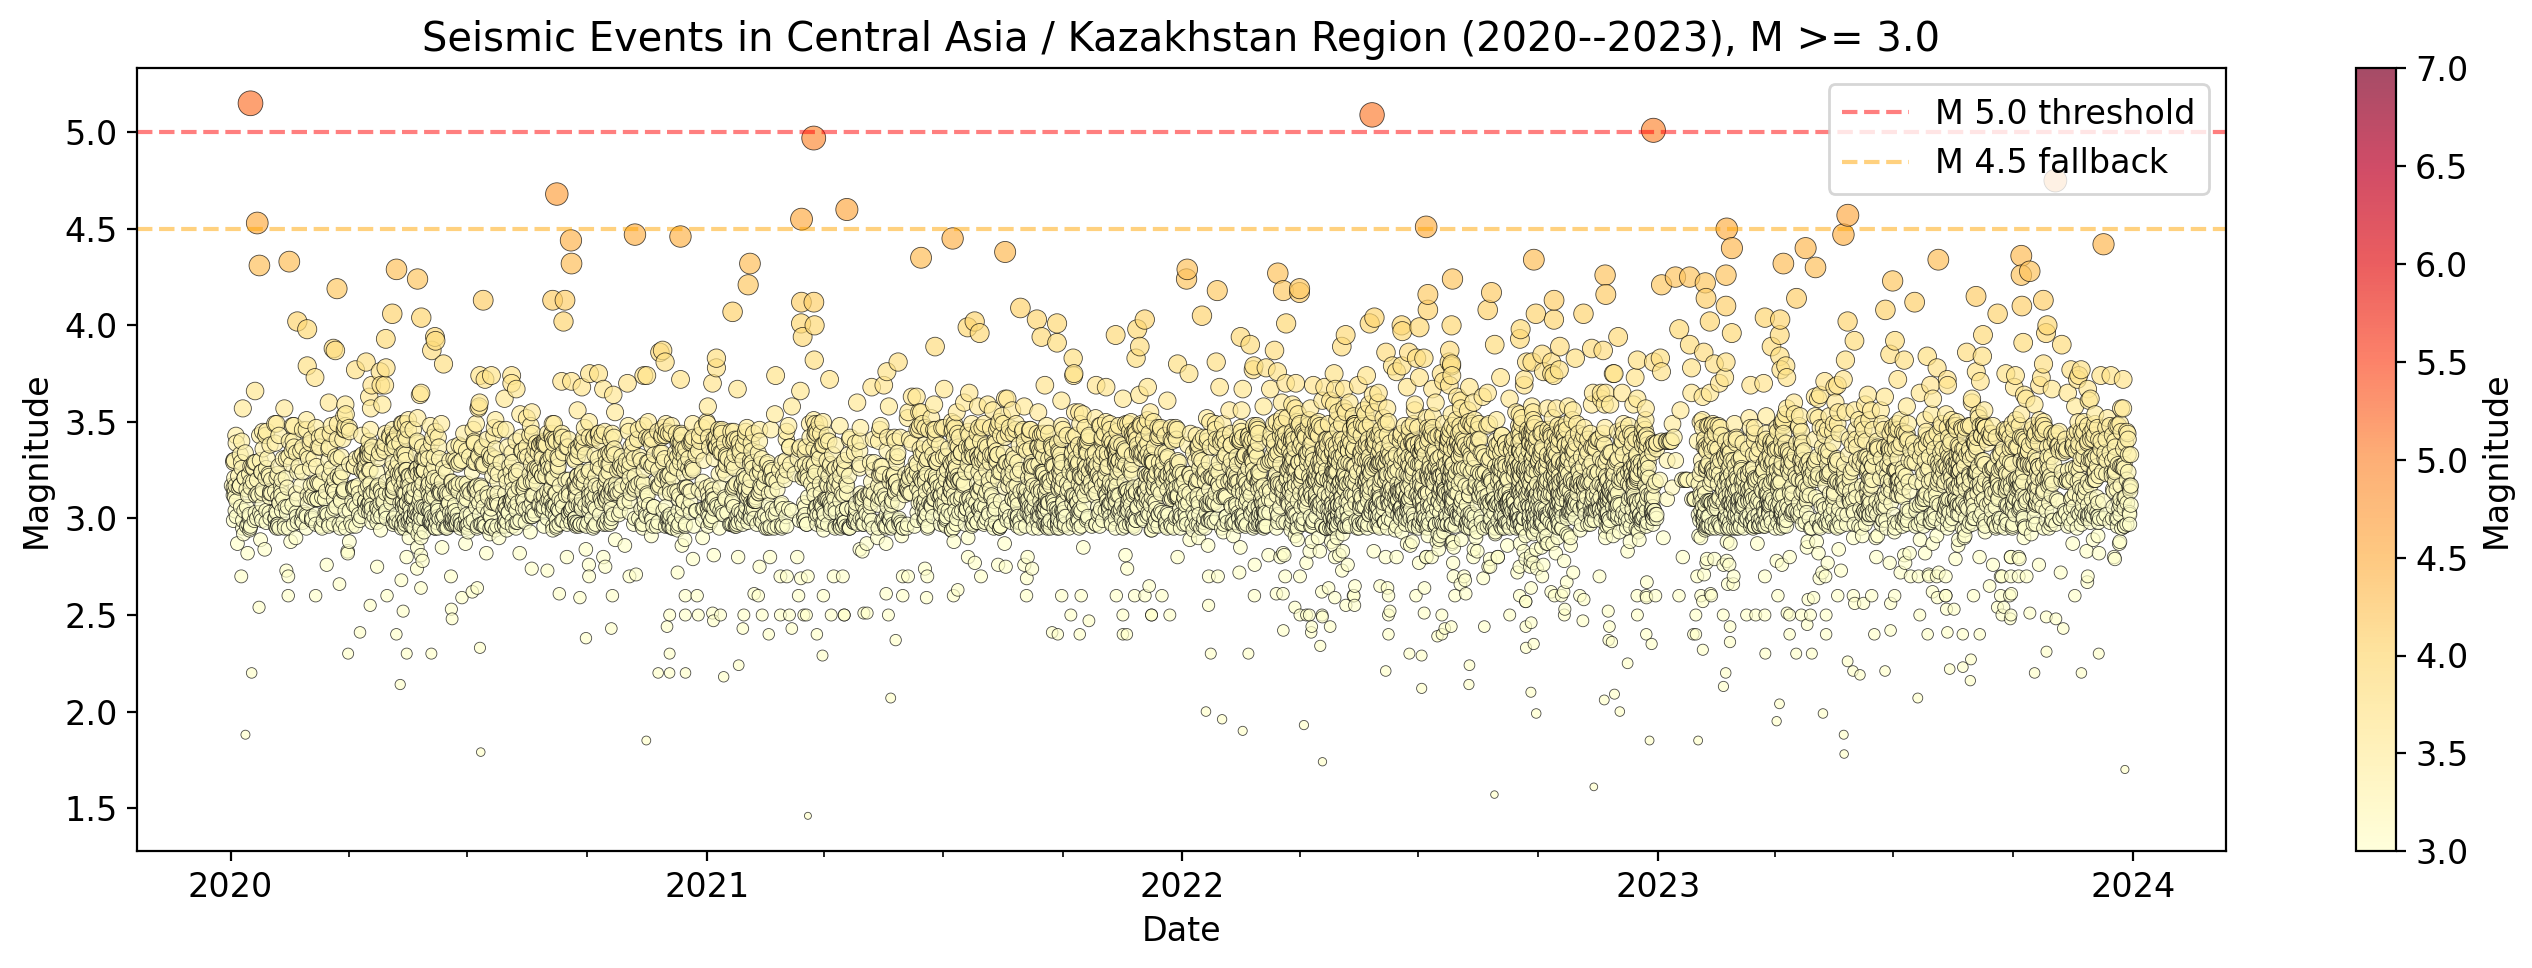

In [12]:
# Timeline of events coloured by magnitude
# Horizontal lines mark the M5.0 Active-regime threshold and M4.5 fallback
fig, ax = plt.subplots(figsize = (14, 5))

scatter = ax.scatter(
    events_df["time"],
    events_df["magnitude"],
    c = events_df["magnitude"],
    cmap = "YlOrRd",
    s = (events_df["magnitude"] ** 2) * 3,
    alpha = 0.7,
    edgecolors = "k",
    linewidths = 0.3,
    vmin = 3.0,
    vmax = 7.0,
)

ax.axhline(y = 5.0, color = "red", linestyle = "--", alpha = 0.5, label = "M 5.0 threshold")
ax.axhline(y = 4.5, color = "orange", linestyle = "--", alpha = 0.5, label = "M 4.5 fallback")

ax.set_xlabel("Date")
ax.set_ylabel("Magnitude")
ax.set_title("Seismic Events in Central Asia / Kazakhstan Region (2020--2023), M >= 3.0")
ax.legend(loc = "upper right")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth = [4, 7, 10]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

cbar = plt.colorbar(scatter, ax = ax, label = "Magnitude")

plt.tight_layout()
plt.show()

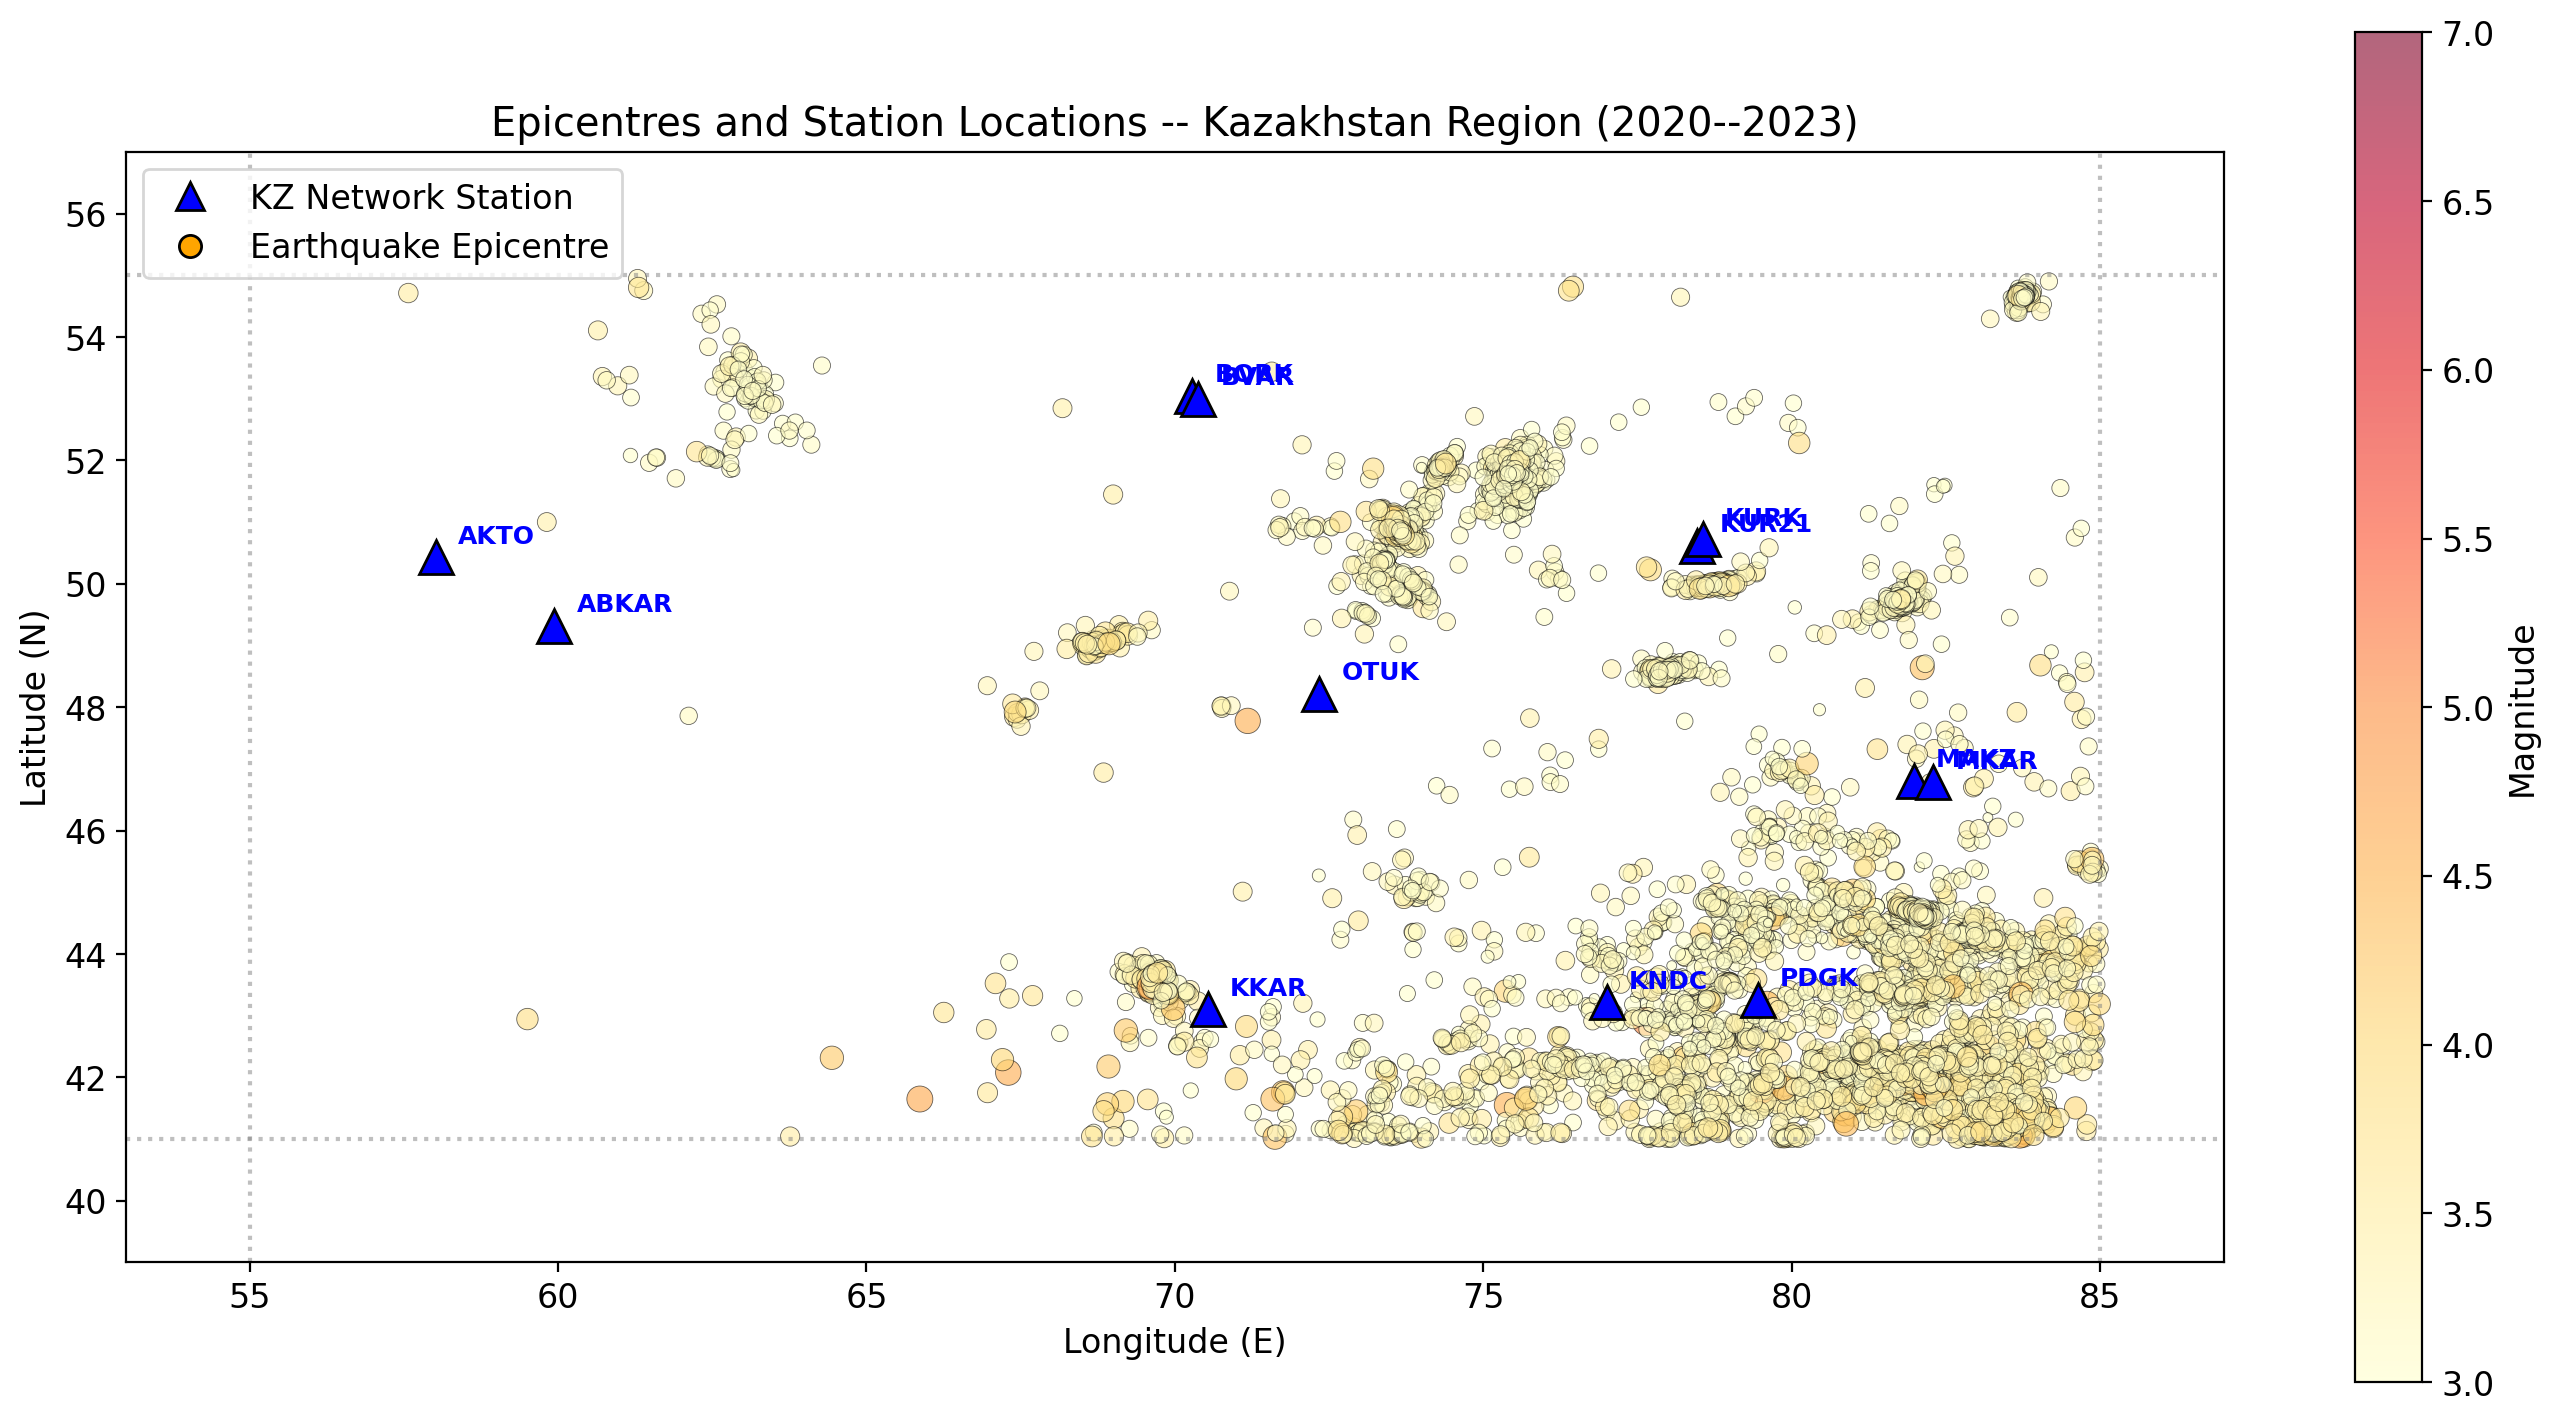

In [13]:
# Map of epicentres with all station locations overlaid
# Grey dashed lines show the bounding box used for the ISC catalog query
fig, ax = plt.subplots(figsize = (14, 10))
scatter = ax.scatter(
    events_df["longitude"],
    events_df["latitude"],
    c = events_df["magnitude"],
    cmap = "YlOrRd",
    s = (events_df["magnitude"] ** 2) * 4,
    alpha = 0.6,
    edgecolors = "k",
    linewidths = 0.3,
    vmin = 3.0,
    vmax = 7.0,
)

# Plot all stations (12 at this point; KUR21 removed after Step 1c)
for name, (lat, lon) in stations.items():
    ax.plot(lon, lat, "^", color = "blue", markersize = 12, markeredgecolor = "k", linewidth = 0.5)
    ax.annotate(name, (lon, lat), textcoords = "offset points", xytext = (8, 5),
                fontsize = 9, fontweight = "bold", color = "blue")

# Bounding box (41-55°N, 55-85°E)
ax.axhline(y = 41, color = "grey", linestyle = ":", alpha = 0.5)
ax.axhline(y = 55, color = "grey", linestyle = ":", alpha = 0.5)
ax.axvline(x = 55, color = "grey", linestyle = ":", alpha = 0.5)
ax.axvline(x = 85, color = "grey", linestyle = ":", alpha = 0.5)

ax.set_xlabel("Longitude (E)")
ax.set_ylabel("Latitude (N)")
ax.set_title("Epicentres and Station Locations -- Kazakhstan Region (2020--2023)")
ax.set_xlim(53, 87)
ax.set_ylim(39, 57)
ax.set_aspect("equal")
cbar = plt.colorbar(scatter, ax = ax, label = "Magnitude", shrink = 0.7)

legend_elements = [
    Line2D([0], [0], marker = "^", color = "w", markerfacecolor = "blue",
           markeredgecolor = "k", markersize = 10, label = "KZ Network Station"),
    Line2D([0], [0], marker = "o", color = "w", markerfacecolor = "orange",
           markeredgecolor = "k", markersize = 8, label = "Earthquake Epicentre"),
]
ax.legend(handles = legend_elements, loc = "upper left")
plt.tight_layout()
plt.show()

### Step 1c: Ground Truth Pick Availability Check

The deferral framework requires ground truth phase picks (human-reviewed P and S arrival times) to evaluate PhaseNet's performance. We query the ISC for events that include arrival data at our 12 stations. The ISC Reviewed Bulletin contains picks that have been manually checked by ISC analysts, which we use as the reference standard.

We request events with `includearrivals=True` to get station-level phase arrival data. To keep the query manageable, we focus on larger events (M >= 4.0) which are more likely to have reviewed picks at multiple stations.

In [16]:
# Query ISC for events with arrival data (phase picks at individual stations)
# Using M >= 4.0 threshold to keep query size manageable
# (full ground truth download at lower magnitudes will be done in later steps)
catalog_with_arrivals = client_isc.get_events(
    starttime = UTCDateTime("2020-01-01"),
    endtime = UTCDateTime("2023-12-31"),
    minlatitude = 41,
    maxlatitude = 55,
    minlongitude = 55,
    maxlongitude = 85,
    minmagnitude = 4.0,
    includearrivals = True,
)
print(f"Events with arrival data (M >= 4.0): {len(catalog_with_arrivals)}")

Events with arrival data (M >= 4.0): 172


We now count how many ISC-reviewed phase picks exist at each of our 12 stations. This tells us how much ground truth data is available for evaluating PhaseNet at each station, and whether any stations should be excluded due to insufficient ground truth.

In [17]:
# Count ISC-reviewed picks per station
# Any station with zero picks cannot be used for evaluation and must be excluded
station_names = set(stations.keys())
pick_counts = {name: 0 for name in station_names}

for event in catalog_with_arrivals:
    for pick in event.picks:
        sta = pick.waveform_id.station_code
        if sta in station_names:
            pick_counts[sta] += 1

print("ISC picks per station:")
for name, count in sorted(pick_counts.items(), key = lambda x: -x[1]):
    print(f"  {name}: {count} picks")

total = sum(pick_counts.values())
stations_with_picks = sum(1 for c in pick_counts.values() if c > 0)
print(f"\nTotal picks across all stations: {total}")
print(f"Stations with at least 1 pick: {stations_with_picks}/12")

ISC picks per station:
  MKAR: 715 picks
  PDGK: 625 picks
  KURK: 624 picks
  MAKZ: 620 picks
  AKTO: 519 picks
  BVAR: 487 picks
  KNDC: 368 picks
  OTUK: 265 picks
  KKAR: 175 picks
  BORK: 158 picks
  ABKAR: 118 picks
  KUR21: 0 picks

Total picks across all stations: 4674
Stations with at least 1 pick: 11/12


### Step 1d: Sample Waveform Download and PhaseNet Test

As a visual sanity check, we download a sample waveform from one Kazakhstan station for a known earthquake in the catalog, run PhaseNet on it, and plot the results. This shows concretely what PhaseNet does with out-of-distribution data from Kazakhstan: it produces picks, but the confidence scores and pick quality may differ from what we would see on California data.

We select a moderate earthquake (M4+) from the catalog that is within a reasonable distance of one of our stations, and download 120 seconds of three-component broadband data.

In [18]:
# Update station list: remove KUR21 (zero ISC picks, cannot evaluate PhaseNet there)
stations = {
    'ABKAR': (49.32, 59.94), 'AKTO': (50.43, 58.02),
    'BORK': (53.05, 70.28), 'BVAR': (53.00, 70.38),
    'KKAR': (43.10, 70.53), 'KNDC': (43.22, 77.00),
    'KURK': (50.72, 78.56), 'MAKZ': (46.81, 81.98),
    'MKAR': (46.79, 82.29), 'OTUK': (48.22, 72.34),
    'PDGK': (43.26, 79.45),
}

# Find the closest M4+ event to any of the 11 stations
# This gives us the best candidate for a clean, high-SNR sanity check
m4_events = events_df[events_df["magnitude"] >= 4.0].copy()

best_dist = np.inf
best_event = None
best_station = None

for name, (slat, slon) in stations.items():
    dists = np.sqrt((m4_events["latitude"] - slat)**2 + (m4_events["longitude"] - slon)**2)
    min_idx = dists.idxmin()
    if dists[min_idx] < best_dist:
        best_dist = dists[min_idx]
        best_event = m4_events.loc[min_idx]
        best_station = name

print(f"Selected event for sample waveform:")
print(f"  Time:      {best_event['time']}")
print(f"  Magnitude: M{best_event['magnitude']:.1f}")
print(f"  Location:  {best_event['latitude']:.2f}N, {best_event['longitude']:.2f}E")
print(f"  Depth:     {best_event['depth_km']:.0f} km")
print(f"  Closest station: {best_station} (~{best_dist:.1f} degrees)")

Selected event for sample waveform:
  Time:      2020-11-06 14:29:28.410000
  Magnitude: M4.5
  Location:  43.19N, 79.60E
  Depth:     12 km
  Closest station: PDGK (~0.2 degrees)


We now download actual seismic waveform data from station PDGK for the selected M4.5 event, to verify that the data pipeline works end-to-end before scaling up to all 11 stations. We need three components (vertical, north-south, and east-west) because PhaseNet requires three-component input.

The download window needs to start before the P-wave arrives at the station so we capture the full waveform from the first arrival onward. Since this event is very close to PDGK (~22km away), seismic waves travel through the crust and arrive within a few seconds of the earthquake origin time. We start the download 5 seconds before the origin time to ensure we capture some quiet background noise before the P-wave hits, which is useful for seeing the contrast between noise and signal. We then record 120 seconds of data, which is long enough to capture both the P-wave arrival (the first, faster wave) and the S-wave arrival (the second, slower wave), plus the coda (the gradual decay of shaking after the main arrivals). These are the two arrivals that PhaseNet will attempt to pick.

In [20]:
# Download three-component waveform from the closest station
# Window: 5 seconds before origin to 115 seconds after (120s total)
event_time = UTCDateTime(best_event["time"])
waveform_start = event_time - 5   # capture pre-arrival noise
waveform_end = event_time + 115   # 120 second window total

st_kz = client_iris.get_waveforms(
    network = "KZ",
    station = "PDGK",
    location = "*",
    channel = "BH*",     # all three broadband components
    starttime = waveform_start,
    endtime = waveform_end,
)

print(f"Downloaded waveform:")
print(st_kz)
for tr in st_kz:
    print(f"  {tr.id}: {tr.stats.npts} samples at {tr.stats.sampling_rate} Hz")

Downloaded waveform:
3 Trace(s) in Stream:
KZ.PDGK..BHE | 2020-11-06T14:29:23.426000Z - 2020-11-06T14:31:23.401000Z | 40.0 Hz, 4800 samples
KZ.PDGK..BHN | 2020-11-06T14:29:23.426000Z - 2020-11-06T14:31:23.401000Z | 40.0 Hz, 4800 samples
KZ.PDGK..BHZ | 2020-11-06T14:29:23.426000Z - 2020-11-06T14:31:23.401000Z | 40.0 Hz, 4800 samples
  KZ.PDGK..BHE: 4800 samples at 40.0 Hz
  KZ.PDGK..BHN: 4800 samples at 40.0 Hz
  KZ.PDGK..BHZ: 4800 samples at 40.0 Hz


We now load PhaseNet and run it on the Kazakhstan waveform. The `annotate` method returns continuous probability traces for P-wave, S-wave, and Noise at each time sample. The `classify` method extracts discrete picks from these traces using peak detection with configurable thresholds.

In [21]:
# Load PhaseNet with original weights (trained on Northern California)
model = sbm.PhaseNet.from_pretrained("original")
print(f"Model loaded. Output labels: {model.labels}")

# annotate() returns continuous probability traces for P, S, and Noise
annotations_kz = model.annotate(st_kz)

# classify() extracts discrete picks from probability traces using peak detection
# Threshold of 0.3: only peaks with probability > 0.3 are reported as picks
output_kz = model.classify(st_kz, P_threshold = 0.3, S_threshold = 0.3)
picks_kz = output_kz.picks

print(f"\nPhaseNet picks on Kazakhstan waveform:")
if len(picks_kz) == 0:
    print("  No picks detected above threshold 0.3.")
    print("  Retrying with lower thresholds (0.1)...")
    output_kz = model.classify(st_kz, P_threshold = 0.1, S_threshold = 0.1)
    picks_kz = output_kz.picks

for pick in picks_kz:
    print(f"  Phase: {pick.phase} | Time: {pick.peak_time} | "
          f"Confidence: {pick.peak_value:.4f}")

Model loaded. Output labels: NPS

PhaseNet picks on Kazakhstan waveform:
  Phase: P | Time: 2020-11-06T14:29:32.966000Z | Confidence: 0.9571
  Phase: S | Time: 2020-11-06T14:29:37.026000Z | Confidence: 0.9436


The plot below shows the three-component waveform in the upper panels and PhaseNet's P-wave and S-wave probability traces in the lower panel. Vertical dashed lines mark the detected picks. This provides a visual assessment of whether PhaseNet's picks align with the visible wave arrivals in the Kazakhstan data.

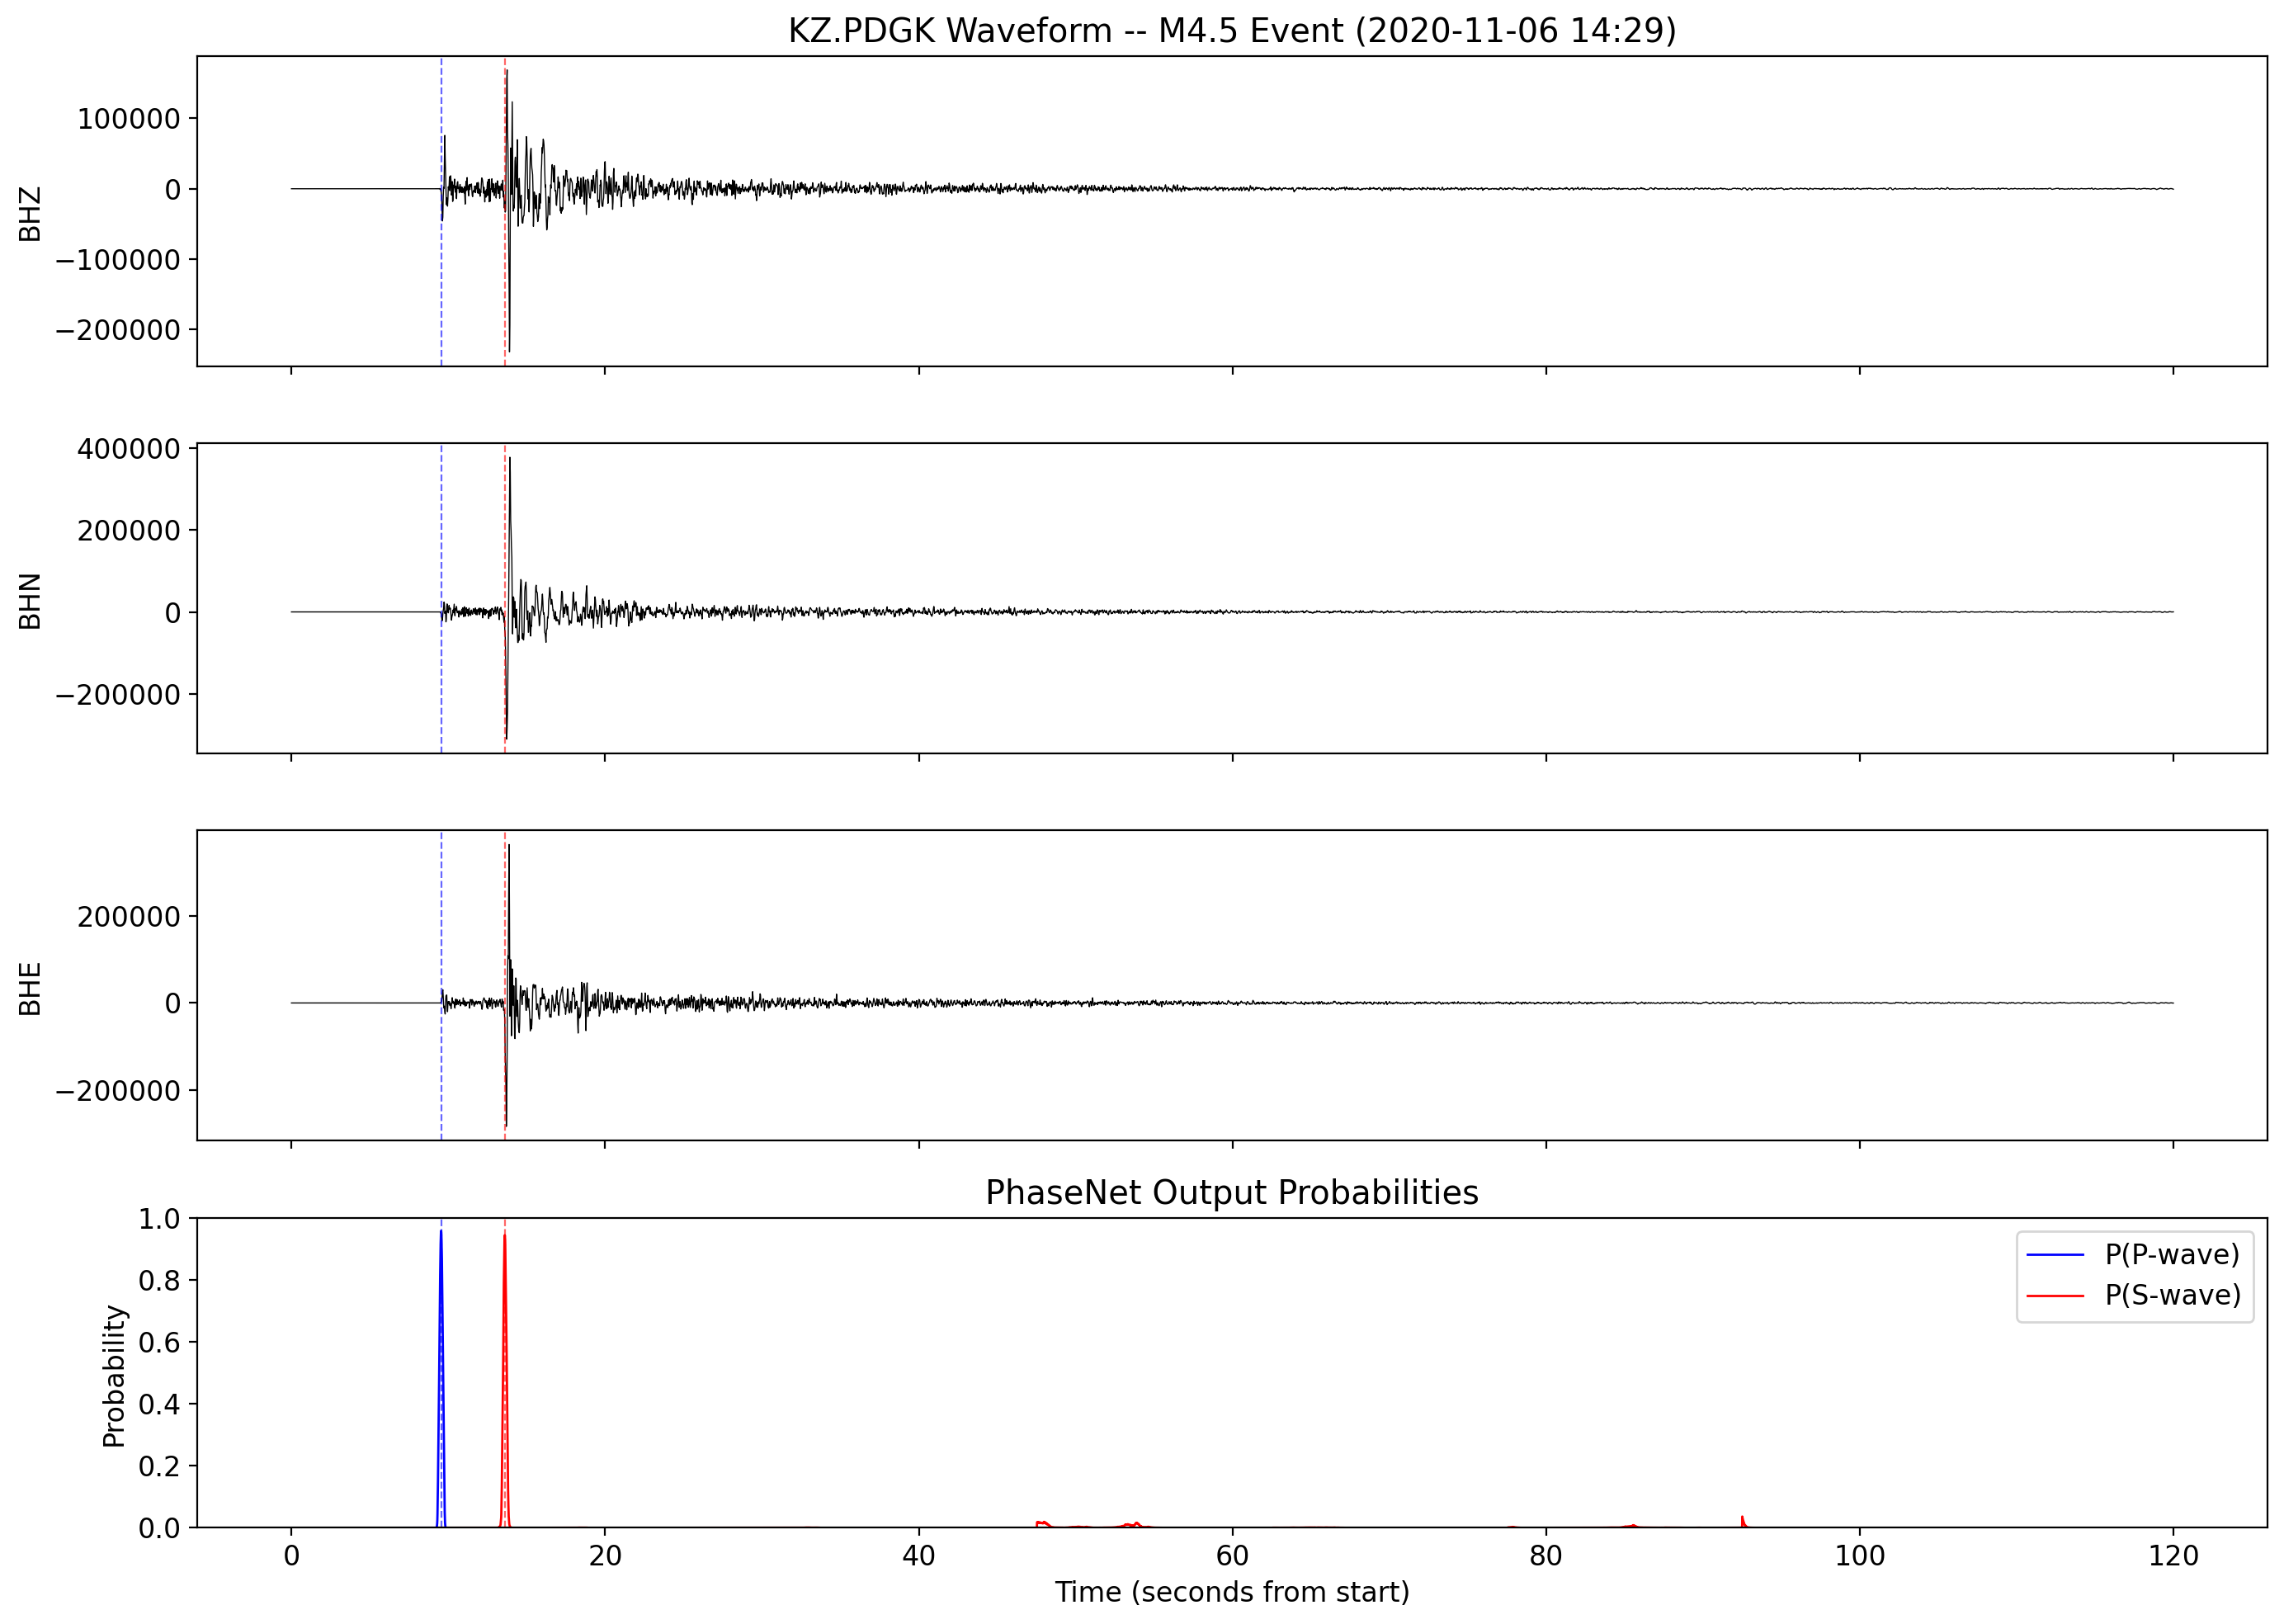

In [22]:
# Plot the 3-component waveform (top 3 panels) with PhaseNet probability traces (bottom panel)
# Vertical dashed lines mark detected picks: blue = P-wave, red = S-wave
fig, axes = plt.subplots(4, 1, figsize = (14, 10), sharex = True)

ref_time = st_kz[0].stats.starttime

# Plot each component (Z, N, E), with fallback to alternative naming (1, 2)
components = ["Z", "N", "E"]
for i, comp in enumerate(components):
    traces = st_kz.select(channel = f"BH{comp}")
    if len(traces) == 0:
        alt = {"N": "1", "E": "2"}.get(comp, comp)
        traces = st_kz.select(channel = f"BH{alt}")
    if len(traces) > 0:
        tr = traces[0]
        t_axis = np.arange(tr.stats.npts) / tr.stats.sampling_rate
        axes[i].plot(t_axis, tr.data, "k", linewidth = 0.5)
        axes[i].set_ylabel(f"BH{comp}")
    else:
        axes[i].set_ylabel(f"BH{comp} (N/A)")

axes[0].set_title(
    f"KZ.PDGK Waveform -- M{best_event['magnitude']:.1f} Event "
    f"({best_event['time'].strftime('%Y-%m-%d %H:%M')})"
)

# Plot PhaseNet probability traces for P and S waves
p_traces = annotations_kz.select(channel = "*_P")
s_traces = annotations_kz.select(channel = "*_S")

if len(p_traces) > 0:
    tr_p = p_traces[0]
    t_prob = np.arange(tr_p.stats.npts) / tr_p.stats.sampling_rate
    offset = tr_p.stats.starttime - ref_time
    axes[3].plot(t_prob + offset, tr_p.data, "b", label = "P(P-wave)", linewidth = 1.0)

if len(s_traces) > 0:
    tr_s = s_traces[0]
    t_prob_s = np.arange(tr_s.stats.npts) / tr_s.stats.sampling_rate
    offset_s = tr_s.stats.starttime - ref_time
    axes[3].plot(t_prob_s + offset_s, tr_s.data, "r", label = "P(S-wave)", linewidth = 1.0)

axes[3].set_ylabel("Probability")
axes[3].set_xlabel("Time (seconds from start)")
axes[3].set_ylim(0, 1)
axes[3].legend(loc = "upper right")
axes[3].set_title("PhaseNet Output Probabilities")

# Mark detected picks on all panels
for pick in picks_kz:
    pick_time = pick.peak_time - ref_time
    colour = "b" if pick.phase == "P" else "r"
    for ax in axes:
        ax.axvline(pick_time, color = colour, linestyle = "--", alpha = 0.6, linewidth = 0.8)

plt.tight_layout()
plt.show()

### Step 1 Summary

The data availability check confirms that the Kazakhstan analysis is feasible. The key findings are:

- **Station availability**: 11 KZ network stations provide three-component broadband data at 40 Hz for 2020--2023 with stable instrumentation throughout the study window. KUR21 was excluded due to having no ISC-reviewed picks.
- **Event catalog**: 6,763 events with M ≥ 3.0, 12 with M ≥ 4.5, and 3 with M ≥ 5.0. Only 4 of the M4.5+ events fall within 200km of any station (KNDC, PDGK, KKAR, OTUK), meaning the remaining 7 stations stay in the Quiet regime throughout the study period. This provides a natural contrast between stations that experience regime transitions and those that do not.
- **Ground truth picks**: 4,674 ISC-reviewed phase picks across the 11 stations (from M4.0+ events), ranging from 118 (ABKAR) to 715 (MKAR). All 11 stations have ground truth data.
- **Sample waveform**: PhaseNet produced confident P and S picks (0.96 and 0.94) on a nearby M4.5 event at PDGK, confirming the pipeline works end-to-end. This is an easy case; performance during Active regime periods with complex waveforms is the core question for the deferral framework.

These results inform the subsequent analysis. The small number of Active-regime transitions (4 events across 4 stations) is a limitation, making the Beta-Bernoulli reliability model's ability to learn from limited data particularly important.

---

## Step 2: California Baseline

To quantify the distribution shift between California and Kazakhstan, we first need a baseline: how well does PhaseNet perform on data from its own training distribution? We run PhaseNet on Northern California waveforms with known human-reviewed picks, and compute standard detection and accuracy metrics. This in-distribution performance serves as the reference against which Kazakhstan performance is compared.

### Step 2a: Load PhaseNet

We load PhaseNet with the "original" pre-trained weights from Zhu and Beroza (2019), trained on approximately 780,000 waveform examples from the Northern California Seismic Network (NCSN). We use these specific weights rather than the "stead" weights because the NCSN training data comes from a single, well-characterised tectonic environment (Northern California), making the distribution shift to Kazakhstan clean and interpretable.

In [23]:
# Load PhaseNet with original weights (Northern California)
model = sbm.PhaseNet.from_pretrained("original")
print(f"PhaseNet loaded successfully.")
print(f"  Output labels: {model.labels}")
print(f"  Expected input: 3-component waveform (Z, N, E)")
print(f"  Output: probability traces for each label at each time sample")

PhaseNet loaded successfully.
  Output labels: NPS
  Expected input: 3-component waveform (Z, N, E)
  Output: probability traces for each label at each time sample


### Step 2b: Download California Test Data

We download waveforms for several well-recorded earthquakes from the Northern California Seismic Network. We select events in the M3-5 range, which are large enough to produce clear P and S arrivals at multiple stations but common enough to provide a reasonable sample size. For each event, we request three-component broadband data (BH* channels) from nearby stations, with a 120-second window centred around the event origin time.

We use the NCEDC FDSN client, which provides direct access to Northern California data.

Note: We select the 10 largest events from the catalog, sorted by magnitude, to maximise signal-to-noise ratio and ensure clear P and S arrivals for the baseline evaluation.

---
- Why M3-5?

The lower bound (M3) ensures clear P and S arrivals that are visible above noise at nearby stations. Below this, arrivals are barely visible above background noise (traffic, wind, ocean waves), and the exact moment the P or S wave arrives is ambiguous. Even experienced human analysts sometimes disagree on the pick time by a second or more. If we cannot trust the ground truth picks, we cannot meaningfully evaluate whether PhaseNet's picks are correct or not.

The upper bound (M5) avoids very large events where the seismometer can saturate or clip, meaning the signal hits the instrument's maximum recording range and the waveform gets cut off. The shaking also lasts much longer and the waveform becomes complex, with surface waves and scattered energy overlapping the main arrivals. This makes it harder to define a single clean P or S arrival time.

Additionally, most of the earthquakes in our Kazakhstan catalog are also in the M3 to M5 range (5,484 out of 6,763 events are M3 to M4, and only 3 exceed M5). By testing PhaseNet on California events of similar size, we ensure the baseline comparison is fair: any performance difference between California and Kazakhstan can be attributed to the geographic distribution shift, not to differences in earthquake size.

- Why 120-second window?

We use a 120-second recording window starting slightly before the earthquake origin time, consistent with the window length used for the Kazakhstan test in Step 1d. This is long enough to capture both the P-wave arrival (which arrives first) and the S-wave arrival (which arrives several seconds later), plus some pre-event noise and post-arrival coda. We download data from multiple stations per event because PhaseNet's performance varies with distance, azimuth, and local noise conditions, so testing across several stations gives a more representative baseline than a single station.

In [24]:
client_ncedc = Client("NCEDC")

# Search for well-recorded California events (M3.5-5.0)
# Northern California region: roughly 35-42N, 118-124W
ca_catalog = client_ncedc.get_events(
    starttime = UTCDateTime("2020-01-01"),
    endtime = UTCDateTime("2023-12-31"),
    minlatitude = 35,
    maxlatitude = 42,
    minlongitude = -124,
    maxlongitude = -118,
    minmagnitude = 3.5,
    maxmagnitude = 5.0,
)

print(f"California events found (M3.5--5.0): {len(ca_catalog)}")

# Select a handful of events spread across the time period
# Parse basic info for selection
ca_events = []
for event in ca_catalog:
    origin = event.preferred_origin()
    mag = event.preferred_magnitude()
    if origin and mag:
        ca_events.append({
            "event": event,
            "time": origin.time,
            "latitude": origin.latitude,
            "longitude": origin.longitude,
            "magnitude": mag.mag,
        })

# Sort by magnitude and pick top events
ca_events.sort(key = lambda x: -x["magnitude"])
selected_ca_events = ca_events[:10]

print(f"\nSelected {len(selected_ca_events)} events for baseline analysis:")
for i, ev in enumerate(selected_ca_events):
    print(f"  {i+1}. {ev['time']} | M{ev['magnitude']:.1f} | "
          f"{ev['latitude']:.2f}N, {ev['longitude']:.2f}W")

California events found (M3.5--5.0): 240

Selected 10 events for baseline analysis:
  1. 2023-09-08T17:24:38.390000Z | M5.0 | 40.95N, -121.56W
  2. 2020-12-01T23:32:56.420000Z | M5.0 | 38.20N, -118.06W
  3. 2020-12-14T21:20:10.880000Z | M4.8 | 38.17N, -118.12W
  4. 2020-12-03T05:15:29.760000Z | M4.8 | 38.20N, -118.06W
  5. 2020-05-15T11:25:43.060000Z | M4.8 | 38.15N, -118.02W
  6. 2020-12-12T07:50:52.940000Z | M4.8 | 38.18N, -118.08W
  7. 2020-03-21T01:33:36.220000Z | M4.7 | 39.11N, -119.72W
  8. 2021-10-25T23:42:35.860000Z | M4.7 | 35.78N, -121.30W
  9. 2021-07-08T23:33:40.900000Z | M4.6 | 38.48N, -119.54W
  10. 2021-05-07T04:35:14.150000Z | M4.6 | 39.46N, -120.31W


For each selected event, we download three-component broadband waveforms from nearby BK (Berkeley Digital Seismic Network) broadband stations. We request data from multiple stations per event to build a meaningful sample of PhaseNet picks for the baseline evaluation.

---
What is in our sample?

We download data from up to 8 stations per event, capped to keep download times manageable while still providing a representative spread of distances and azimuths around each event. Across 10 events, this gives roughly 80 station-event waveform pairs, each producing an independent PhaseNet pick that can be compared against ground truth. We use 10 events rather than 5 to ensure a robust sample of P-wave picks, since the NCEDC catalog predominantly reports P-wave arrivals and S picks are sparse. The NCEDC catalog predominantly reports P-wave arrivals; S picks are sparse because S arrivals are harder to identify precisely, arriving on top of the P-wave coda. The California baseline therefore primarily evaluates P-wave picking performance.

In [25]:
# Download waveforms for each selected California event
# Up to 8 BK (Berkeley) broadband stations per event within 2 degrees
ca_waveforms = []

for ev in selected_ca_events:
    origin_time = ev["time"]
    win_start = origin_time - 10
    win_end = origin_time + 110

    # Search BK network (Berkeley) which has broadband BH* stations
    try:
        inv = client_ncedc.get_stations(
            network = "BK",
            channel = "BH*",
            starttime = win_start,
            endtime = win_end,
            latitude = ev["latitude"],
            longitude = ev["longitude"],
            maxradius = 2.0,
            level = "station",
        )
    except Exception as e:
        print(f"\nEvent M{ev['magnitude']:.1f} ({ev['time'].date}): no stations found")
        continue

    station_codes = []
    for net in inv:
        for sta in net:
            station_codes.append(sta.code)

    # Cap at 8 stations per event to keep download times manageable
    station_codes = station_codes[:8]

    print(f"\nEvent M{ev['magnitude']:.1f} ({ev['time'].date}): "
          f"{len(station_codes)} stations available")

    for sta_code in station_codes:
        try:
            st = client_ncedc.get_waveforms(
                network = "BK",
                station = sta_code,
                location = "*",
                channel = "BH*",
                starttime = win_start,
                endtime = win_end,
            )
            if len(st) >= 3:
                ca_waveforms.append((ev, sta_code, st))
                print(f"  {sta_code}: {len(st)} traces downloaded")
        except:
            print(f"  {sta_code}: download failed, skipping")

print(f"\nTotal station-event waveform pairs: {len(ca_waveforms)}")


Event M5.0 (2023-09-08): 8 stations available
  AONC: 3 traces downloaded
  BAKR: 3 traces downloaded
  BAYL: 3 traces downloaded
  BCCR: 3 traces downloaded
  BIGV: 3 traces downloaded
  BJES: 3 traces downloaded
  BLAS: 3 traces downloaded
  BOYR: 3 traces downloaded

Event M5.0 (2020-12-01): 8 stations available
  BUCR: 3 traces downloaded
  CGRV: 3 traces downloaded
  CMB: 3 traces downloaded
  HELL: 3 traces downloaded
  KARE: 3 traces downloaded
  LEGD: 3 traces downloaded
  OVRO: 3 traces downloaded
  TOLH: 3 traces downloaded

Event M4.8 (2020-12-14): 8 stations available
  BUCR: 3 traces downloaded
  CGRV: 3 traces downloaded
  CMB: 3 traces downloaded
  HELL: 3 traces downloaded
  KARE: 3 traces downloaded
  LEGD: 3 traces downloaded
  LIND: 3 traces downloaded
  OVRO: 3 traces downloaded

Event M4.8 (2020-12-03): 8 stations available
  BUCR: 3 traces downloaded
  CGRV: 3 traces downloaded
  CMB: 3 traces downloaded
  HELL: 3 traces downloaded
  KARE: 3 traces downloaded
  L

### Step 2c: Get California Ground Truth Picks

We retrieve the NCEDC catalog picks for the same events. These are the human-reviewed P and S arrival times that serve as ground truth for evaluating PhaseNet. We query the NCEDC event service directly with includearrivals=True, filtering to BK network picks at stations for which we have downloaded waveforms. This ensures a one-to-one correspondence between ground truth picks and available waveform data.

The NCEDC catalog returned 64 ground truth picks across 27 stations, of which 62 are P-wave picks and only 2 are S-wave picks. This heavy P-wave bias is a known characteristic of routine catalog processing: S arrivals are harder to identify precisely because they arrive on top of the P-wave coda, so regional catalogues often omit them. The California baseline therefore primarily reflects P-wave picking performance. S-wave baseline coverage will depend on the availability of S picks in the ISC Reviewed Bulletin for the Kazakhstan analysis.

In [26]:
# Get ground truth picks from the NCEDC catalog (better coverage for California events)
ca_ground_truth = []

# Build set of (station, event_time) pairs we actually have waveforms for
downloaded_pairs = set((sta_code, str(ev["time"])) for ev, sta_code, _ in ca_waveforms)

for ev in selected_ca_events:
    origin_time = ev["time"]

    try:
        cat = client_ncedc.get_events(
            starttime = origin_time - 5,
            endtime = origin_time + 5,
            minmagnitude = ev["magnitude"] - 0.2,
            maxmagnitude = ev["magnitude"] + 0.2,
            includearrivals = True,
        )
    except Exception as e:
        print(f"  Event M{ev['magnitude']:.1f} ({origin_time.date}): query failed, skipping")
        continue

    if len(cat) == 0:
        print(f"  No event found for M{ev['magnitude']:.1f} at {origin_time}")
        continue

    event = cat[0]
    origin = event.preferred_origin()
    if origin is None:
        continue

    pick_lookup = {}
    for pick in event.picks:
        pick_lookup[pick.resource_id.id] = pick

    event_picks = 0
    for arrival in origin.arrivals:
        pick_id = arrival.pick_id.id
        if pick_id not in pick_lookup:
            continue
        pick = pick_lookup[pick_id]

        if pick.waveform_id.network_code != "BK":
            continue

        # Only keep picks for station-event pairs we actually downloaded waveforms for
        if (pick.waveform_id.station_code, str(origin_time)) not in downloaded_pairs:
            continue

        phase_hint = pick.phase_hint if pick.phase_hint else str(arrival.phase)
        if phase_hint not in ["P", "Pg", "Pn", "S", "Sg", "Sn"]:
            continue

        phase_type = "P" if phase_hint.startswith("P") else "S"

        ca_ground_truth.append({
            "event_time": origin_time,
            "event_mag": ev["magnitude"],
            "station": pick.waveform_id.station_code,
            "network": pick.waveform_id.network_code,
            "phase": phase_type,
            "pick_time": pick.time,
        })
        event_picks += 1

    print(f"  Event M{ev['magnitude']:.1f} ({origin_time.date}): {event_picks} BK P/S picks")

ca_gt_df = pd.DataFrame(ca_ground_truth)
print(f"\nTotal ground truth picks: {len(ca_gt_df)}")
if len(ca_gt_df) > 0:
    print(f"  P picks: {len(ca_gt_df[ca_gt_df['phase'] == 'P'])}")
    print(f"  S picks: {len(ca_gt_df[ca_gt_df['phase'] == 'S'])}")
    print(f"  Stations with picks: {ca_gt_df['station'].nunique()}")

  Event M5.0 (2023-09-08): 8 BK P/S picks
  Event M5.0 (2020-12-01): 6 BK P/S picks
  Event M4.8 (2020-12-14): 7 BK P/S picks
  Event M4.8 (2020-12-03): 7 BK P/S picks
  Event M4.8 (2020-05-15): 4 BK P/S picks
  Event M4.8 (2020-12-12): 6 BK P/S picks
  Event M4.7 (2020-03-21): 7 BK P/S picks
  Event M4.7 (2021-10-25): 6 BK P/S picks
  Event M4.6 (2021-07-08): 5 BK P/S picks
  Event M4.6 (2021-05-07): 8 BK P/S picks

Total ground truth picks: 64
  P picks: 62
  S picks: 2
  Stations with picks: 27


### Step 2d: Run PhaseNet on California Data and Compute Baseline Metrics

We now run PhaseNet on each California waveform and compare the detected picks against the catalog ground truth. For each waveform, we extract PhaseNet's discrete picks (using the default 0.3 probability threshold) and attempt to match them to the corresponding catalog picks.

A PhaseNet pick is considered a correct detection if it falls within 0.5 seconds of a catalog pick of the same phase type (P or S). This 0.5-second tolerance is standard in the seismological literature for evaluating automated pickers.

We compute the following metrics:
- **Pick residuals**: PhaseNet pick time minus catalog pick time (in seconds), measuring systematic bias and scatter.
- **Detection rate**: the fraction of catalog picks that PhaseNet successfully detects.
- **False pick rate**: the fraction of PhaseNet picks that have no corresponding catalog pick.
- **Confidence score distribution**: the distribution of PhaseNet's output confidence for detected picks.

---
- Why 0.3 threshold?

This is the default threshold in SeisBench's PhaseNet implementation. The original paper (Zhu and Beroza, 2019) used a stricter 0.5 threshold. Threshold sensitivity analysis is a potential extension.

- Why 0.5 seconds?

Zhu and Beroza (2019) used a stricter 0.1-second tolerance for true positives in their controlled evaluation, where training and test data came from the same processing pipeline. We use a more relaxed 0.5-second tolerance because we are comparing PhaseNet picks against independently processed catalog arrival times, which may have small systematic timing differences. This tolerance is a tunable parameter and could be tightened in future analysis.

In [27]:
# Run PhaseNet on each California waveform and compare to ground truth
MATCH_TOLERANCE = 0.5  # seconds

results = []  # one row per PhaseNet pick
gt_matched = []  # tracking which ground truth picks were detected

for ev_info, sta_code, st in ca_waveforms:
    # Run PhaseNet
    output = model.classify(st, P_threshold = 0.3, S_threshold = 0.3)
    pn_picks = output.picks

    # Get ground truth picks for this event-station pair
    event_time = ev_info["time"]
    gt_picks = ca_gt_df[
        (ca_gt_df["station"] == sta_code) &
        (abs((ca_gt_df["event_time"] - event_time)) < 10)
    ]

    # Match each PhaseNet pick to the closest ground truth pick of the same phase
    matched_gt_indices = set()

    for pn_pick in pn_picks:
        phase = pn_pick.phase
        pn_time = pn_pick.peak_time
        confidence = pn_pick.peak_value

        # Find closest ground truth pick of same phase
        same_phase_gt = gt_picks[gt_picks["phase"] == phase]
        best_residual = None
        best_idx = None

        for idx, gt_row in same_phase_gt.iterrows():
            residual = pn_time - gt_row["pick_time"]
            if best_residual is None or abs(residual) < abs(best_residual):
                best_residual = residual
                best_idx = idx

        is_match = (best_residual is not None and abs(best_residual) <= MATCH_TOLERANCE)

        results.append({
            "event_time": event_time.datetime,
            "event_mag": ev_info["magnitude"],
            "station": sta_code,
            "phase": phase,
            "pn_time": pn_time.datetime,
            "confidence": confidence,
            "matched": is_match,
            "residual": best_residual if is_match else np.nan,
        })

        if is_match and best_idx is not None:
            matched_gt_indices.add(best_idx)

    # Record which ground truth picks were detected
    for idx, gt_row in gt_picks.iterrows():
        gt_matched.append({
            "station": sta_code,
            "phase": gt_row["phase"],
            "detected": idx in matched_gt_indices,
        })

results_df = pd.DataFrame(results)
gt_matched_df = pd.DataFrame(gt_matched)

print(f"PhaseNet picks generated: {len(results_df)}")
print(f"Ground truth picks checked: {len(gt_matched_df)}")

PhaseNet picks generated: 140
Ground truth picks checked: 64


NOTE:

PhaseNet generated 140 picks across 72 waveforms, approximately 2 per waveform (one P and one S). All 64 ground truth picks were checked for matches. The difference between 140 PhaseNet picks and 64 ground truth picks is expected: PhaseNet detects both P and S arrivals on most waveforms, but the NCEDC catalog only reports 2 S picks out of 64 total. This means the majority of PhaseNet's S-wave detections have no catalog pick to validate against and will appear as unmatched picks. The false pick rate for S waves should therefore be interpreted with caution, as many of these "false" picks may be correct detections that the catalog simply did not include.

We now compute and display the baseline metrics. These numbers represent PhaseNet's in-distribution performance and serve as the reference point for the distribution shift analysis.

In [28]:
# Compute baseline metrics
print("=" * 60)
print("PhaseNet California Baseline Metrics")
print("=" * 60)

# Detection rate
if len(gt_matched_df) > 0:
    detection_rate = gt_matched_df["detected"].mean()
    print(f"\nOverall detection rate: {detection_rate:.3f} "
          f"({gt_matched_df['detected'].sum()}/{len(gt_matched_df)})")

    for phase in ["P", "S"]:
        phase_gt = gt_matched_df[gt_matched_df["phase"] == phase]
        if len(phase_gt) > 0:
            rate = phase_gt["detected"].mean()
            print(f"  {phase}-wave detection rate: {rate:.3f} "
                  f"({phase_gt['detected'].sum()}/{len(phase_gt)})")

# False pick rate
if len(results_df) > 0:
    false_rate = (~results_df["matched"]).mean()
    print(f"\nFalse pick rate: {false_rate:.3f} "
          f"({(~results_df['matched']).sum()}/{len(results_df)})")

    for phase in ["P", "S"]:
        phase_results = results_df[results_df["phase"] == phase]
        if len(phase_results) > 0:
            phase_false = (~phase_results["matched"]).mean()
            print(f"  {phase}-wave false pick rate: {phase_false:.3f} "
                  f"({(~phase_results['matched']).sum()}/{len(phase_results)})")

# Pick residuals
matched = results_df[results_df["matched"]]
if len(matched) > 0:
    print(f"\nPick residuals (PhaseNet - catalog):")
    print(f"  Mean:   {matched['residual'].mean():+.4f} s")
    print(f"  Std:    {matched['residual'].std():.4f} s")
    print(f"  Median: {matched['residual'].median():+.4f} s")
    print(f"  MAE:    {matched['residual'].abs().mean():.4f} s")

    for phase in ["P", "S"]:
        phase_matched = matched[matched["phase"] == phase]
        if len(phase_matched) > 0:
            print(f"\n  {phase}-wave residuals:")
            print(f"    Mean: {phase_matched['residual'].mean():+.4f} s")
            print(f"    Std:  {phase_matched['residual'].std():.4f} s")
            print(f"    MAE:  {phase_matched['residual'].abs().mean():.4f} s")

# Confidence distribution
if len(matched) > 0:
    print(f"\nConfidence scores (matched picks):")
    print(f"  Mean:   {matched['confidence'].mean():.3f}")
    print(f"  Median: {matched['confidence'].median():.3f}")
    print(f"  Std:    {matched['confidence'].std():.3f}")
    print(f"  Min:    {matched['confidence'].min():.3f}")
    print(f"  Max:    {matched['confidence'].max():.3f}")

PhaseNet California Baseline Metrics

Overall detection rate: 0.859 (55/64)
  P-wave detection rate: 0.855 (53/62)
  S-wave detection rate: 1.000 (2/2)

False pick rate: 0.607 (85/140)
  P-wave false pick rate: 0.354 (29/82)
  S-wave false pick rate: 0.966 (56/58)

Pick residuals (PhaseNet - catalog):
  Mean:   +0.0347 s
  Std:    0.0959 s
  Median: +0.0350 s
  MAE:    0.0767 s

  P-wave residuals:
    Mean: +0.0331 s
    Std:  0.0932 s
    MAE:  0.0741 s

  S-wave residuals:
    Mean: +0.0780 s
    Std:  0.2034 s
    MAE:  0.1438 s

Confidence scores (matched picks):
  Mean:   0.732
  Median: 0.756
  Std:    0.150
  Min:    0.315
  Max:    0.939


**California Baseline Summary**

PhaseNet achieves an 85.9% detection rate (55/64) on in-distribution California data, successfully identifying 53 of 62 catalog P arrivals and both S arrivals. P-wave pick residuals have a mean of +0.033s and standard deviation of 0.093s, indicating PhaseNet picks slightly late relative to analyst picks, with scatter close to the 0.1s true-positive threshold used by Zhu and Beroza (2019). Mean confidence for matched picks is 0.732.

The overall false pick rate of 60.7% (85/140) is misleading and must be interpreted with the per-phase breakdown. The P-wave false pick rate is 35.4% (29/82), while the S-wave false pick rate is 96.6% (56/58). The S-wave rate is almost entirely an artefact of ground truth sparsity: the NCEDC catalog contains only 2 S picks out of 64 total, so PhaseNet's S detections have no reference to validate against. This does not mean PhaseNet is generating incorrect S picks.

**Key points for future analysis:**

- The P-wave detection rate of 85.5% (53/62) and residual statistics (mean +0.033s, std 0.093s, MAE 0.074s) are the primary baseline reference for comparison with Kazakhstan.
- The S-wave baseline is incomplete due to NCEDC catalog limitations. If the ISC Reviewed Bulletin provides sufficient S picks for Kazakhstan, S-wave performance can be evaluated there but cannot be compared against a California baseline.
- Some of the 29 unmatched P picks may be correct detections of arrivals not in the catalog, so 35.4% (29/82) is an upper bound on the true P-wave false pick rate.
- The 9 missed P arrivals (9/62 = 14.5% miss rate) warrant investigation in later analysis to determine whether they correlate with low SNR, large epicentral distance, or specific stations.

The histogram below shows the distribution of pick residuals (PhaseNet time minus catalog time) for the California baseline. A well-performing picker should produce a narrow, symmetric distribution centred near zero. The spread of this distribution quantifies PhaseNet's precision on in-distribution data.

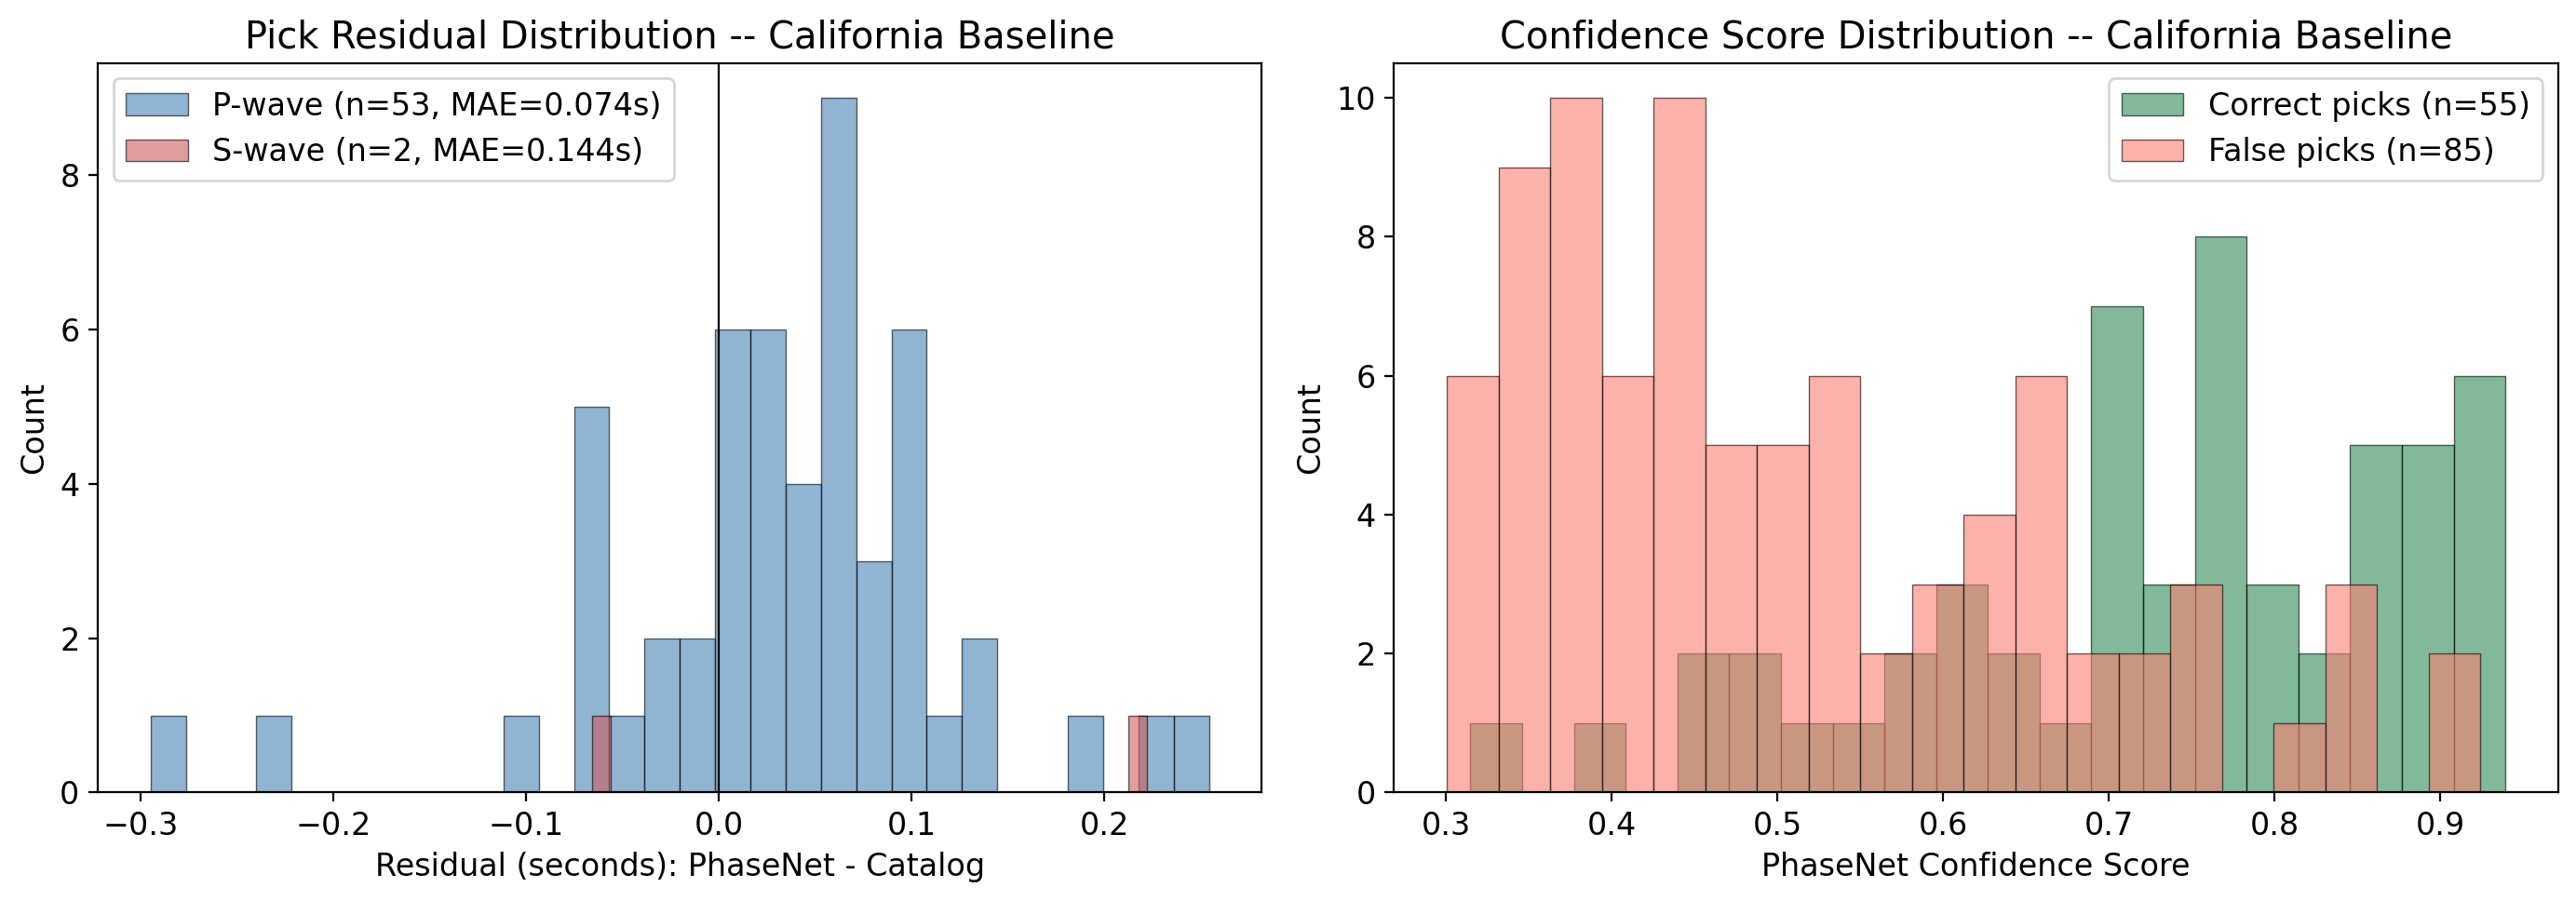

In [29]:
# Plot pick residual histogram
if len(matched) > 0:
    fig, axes = plt.subplots(1, 2, figsize = (14, 5))

    # Left panel: residual histogram by phase
    for phase, colour in [("P", "steelblue"), ("S", "indianred")]:
        phase_data = matched[matched["phase"] == phase]["residual"]
        if len(phase_data) > 0:
            axes[0].hist(
                phase_data,
                bins = 30,
                alpha = 0.6,
                color = colour,
                label = f"{phase}-wave (n={len(phase_data)}, "
                        f"MAE={phase_data.abs().mean():.3f}s)",
                edgecolor = "k",
                linewidth = 0.5,
            )

    axes[0].axvline(0, color = "k", linestyle = "-", linewidth = 0.8)
    axes[0].set_xlabel("Residual (seconds): PhaseNet - Catalog")
    axes[0].set_ylabel("Count")
    axes[0].set_title("Pick Residual Distribution -- California Baseline")
    axes[0].legend()

    # Right panel: confidence score distribution
    matched_conf = matched["confidence"]
    unmatched_conf = results_df[~results_df["matched"]]["confidence"]

    if len(matched_conf) > 0:
        axes[1].hist(
            matched_conf,
            bins = 20,
            alpha = 0.6,
            color = "seagreen",
            label = f"Correct picks (n={len(matched_conf)})",
            edgecolor = "k",
            linewidth = 0.5,
        )
    if len(unmatched_conf) > 0:
        axes[1].hist(
            unmatched_conf,
            bins = 20,
            alpha = 0.6,
            color = "salmon",
            label = f"False picks (n={len(unmatched_conf)})",
            edgecolor = "k",
            linewidth = 0.5,
        )

    axes[1].set_xlabel("PhaseNet Confidence Score")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Confidence Score Distribution -- California Baseline")
    axes[1].legend()

    plt.tight_layout()
    plt.show()
else:
    print("No matched picks to plot. Check data availability.")

**Left panel (Residuals):** The P-wave residuals are centred slightly above zero, confirming PhaseNet picks arrive a fraction after the analyst picks. The bulk of the distribution falls within ±0.1s, consistent with high-quality picking. A few outliers at -0.3s and +0.2s suggest occasional poor picks, likely on noisy or emergent arrivals. The 2 S-wave residuals are too few to draw conclusions.

**Right panel (Confidence):** This is the more interesting plot. Correct picks (green) tend towards higher confidence scores (0.7 to 0.9), while "false" picks (salmon) peak at lower confidence scores (0.3 to 0.5). There is partial separation between the two distributions, suggesting confidence scores carry some information about pick quality, though the substantial overlap indicates confidence alone would not be sufficient for deferral decisions.

However, the "false" picks label must be interpreted with caution. The 85 unmatched picks include approximately 56 S-wave detections that have no catalog ground truth to validate against. These are not necessarily wrong -- they appear as "false" only because the NCEDC catalog omits most S arrivals. The low-confidence cluster in the salmon distribution likely reflects a mix of genuinely incorrect picks and valid S-wave detections that PhaseNet is less confident about (S arrivals are inherently harder to pick because they arrive on top of P-wave coda). Separating these two effects would require independent S-wave ground truth, which the NCEDC catalog cannot provide.

### Step 2 Summary

The California baseline establishes PhaseNet's in-distribution performance. PhaseNet achieves a P-wave detection rate of 85.5% (53/62) with pick residuals of +0.033s mean and 0.093s standard deviation, and mean confidence of 0.732 for matched picks. The P-wave false pick rate of 35.4% (29/82) is an upper bound, as some unmatched picks may be correct detections absent from the catalog. The S-wave baseline is incomplete due to NCEDC catalog sparsity (only 2 S picks out of 64 total), so the 96.6% S-wave false pick rate reflects a ground truth gap rather than poor model performance. The confidence score distribution shows partial separation between matched and unmatched picks, suggesting confidence scores carry some information about pick quality, though the overlap indicates confidence alone would not be sufficient for deferral decisions.

These metrics provide the quantitative reference against which we will measure the distribution shift to Kazakhstan in subsequent analysis stages. Any degradation observed on Kazakhstan data relative to these baseline figures can be attributed to the distribution shift between the two regions. This degradation is the quantitative evidence that motivates the deferral framework: if the model's reliability drops under distribution shift, we need a mechanism to detect and manage that drop.